# ¿Quién pudo quedarse en casa?

### Cómo una pregunta de pronóstico se topó con una pared, y qué pregunta quedó del otro lado

Este notebook cuenta una investigación en el orden en que ocurrió. Empieza con la
pregunta más natural que se le puede hacer a una red de movilidad (*¿cuántos viajes
tendrá mañana cada conexión?*) y la sigue hasta donde el dato deja de responder. Ahí
cambia de pregunta.

**Los datos.** Redes diarias de movilidad de la Zona Metropolitana del Valle de México,
construidas a partir de trazas GPS anónimas de celulares: un archivo por día del 1 de
enero de 2020 al 31 de marzo de 2021. Cada archivo lista conexiones entre AGEBs (las
unidades territoriales del INEGI, del tamaño de unas cuantas manzanas) con un peso $w$
= viajes por millón de dispositivos observados ese día. El $w$ mínimo de cada día
equivale a un viaje, así que dividir entre él recupera el conteo crudo.

**Mapa de ruta.**

1. La pregunta obvia: predecir el mañana. Los datos, el split, la métrica y los baselines.
2. Un modelo entrenado. Funciona, pero apenas mejora a un promedio.
3. Cambiar la pregunta: no *el mañana*, sino *qué lugares pudieron dejar de moverse*.
4. Un control negativo y una prueba de fiabilidad antes de creer nada.
5. El experimento, con un test espacial honesto.
6. Resultados, calculados al final.

Todo se calcula aquí, desde los archivos originales. La primera corrida tarda unos
tres minutos (construye un caché y entrena); las siguientes, poco más de uno.

In [1]:
# Librerías
from pathlib import Path
import json as _json
import warnings
warnings.filterwarnings("ignore")

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Polygon
from scipy import stats
from scipy.spatial import ConvexHull, cKDTree
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
import shap
from xgboost import XGBRegressor

from datos import find_data_dir, leer_dia

# Paleta de colores y estilo de gráficas
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2de"
AZUL, NARANJA, AQUA, ROJO, GRIS = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#c9c8c3"
CATEG = [AZUL, NARANJA, AQUA, "#eda100", "#e87ba4", "#008300", "#4a3aa7", ROJO]
DIVERGENTE = LinearSegmentedColormap.from_list("azul_rojo", [AZUL, "#f0efec", ROJO])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12.5, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10, "figure.dpi": 110,
})
pd.set_option("display.width", 120)

# Rutas y catálogo de AGEBs
DATA = find_data_dir()
# Las claves del INEGI llevan ceros a la izquierda: se leen como texto o se rompen.
nodos = pd.read_csv(DATA / "agebs_ZMVM.csv", dtype={"IDGEO": str}).set_index("IDGEO")
# Población municipal a número
nodos["Pob_MUN"] = pd.to_numeric(nodos.Pob_MUN.str.replace(" ", "", regex=False), errors="coerce")

# Verificación
print("Datos en:", DATA.name)   # solo el nombre, sin la ruta de la computadora
nodos.head()

Datos en: gwq6u-osfstorage-archive


,ID_ENT,ID_MUN,ID_LOC,ID_AGEB,Entity,Municipality,Type,Long,Lat,Pob_MUN
IDGEO,,,,,,,,,,
090040335,9,4,NaN,0335,Ciudad de México,Cuajimalpa,Rural,-99.309828,19.366250,217686
090040157,9,4,NaN,0157,Ciudad de México,Cuajimalpa,Rural,-99.327986,19.296067,217686
090080368,9,8,NaN,0368,Ciudad de México,La Magdalena Contreras,Rural,-99.278831,19.252167,247622
090121250,9,12,NaN,1250,Ciudad de México,Tlalpan,Rural,-99.204483,19.138433,699928
090121829,9,12,NaN,1829,Ciudad de México,Tlalpan,Rural,-99.144820,19.174985,699928


# 1. La pregunta obvia: predecir el mañana

Un archivo diario se ve así: una fila por conexión, con el AGEB de origen, el de destino
y cuántos viajes hubo. El peso `w` original viene normalizado por dispositivos; `v` es
el conteo crudo reconstruido.

In [2]:
# Un día de ejemplo
un_dia = leer_dia("2020-09-16")
print(f"16 de septiembre de 2020: {len(un_dia):,} conexiones, {un_dia.v.sum():,} viajes")
un_dia.head()

16 de septiembre de 2020: 248,245 conexiones, 1,654,021 viajes


,source,target,v
0,0900300010037,0900300010041,197
1,0901600011052,0901600011298,3
2,0900700010214,0900700012390,1
3,090140001083A,090140001076A,59
4,1505700010813,1505700012576,8


In [3]:
# Los viajes por conexión: la mayoría es un solo viaje.
resumen_v = (un_dia.v.clip(upper=10).value_counts().sort_index()
             .rename("conexiones").to_frame()
             .assign(porcentaje=lambda d: (d.conexiones / len(un_dia) * 100).round(1)))
resumen_v.index = [str(i) for i in range(1, 10)] + ["10 o más"]
resumen_v.index.name = "viajes"
resumen_v

,conexiones,porcentaje
viajes,,
1,143883,58.0
2,31390,12.6
3,14550,5.9
4,8578,3.5
5,5891,2.4
6,4239,1.7
7,3412,1.4
8,2691,1.1
9,2273,0.9


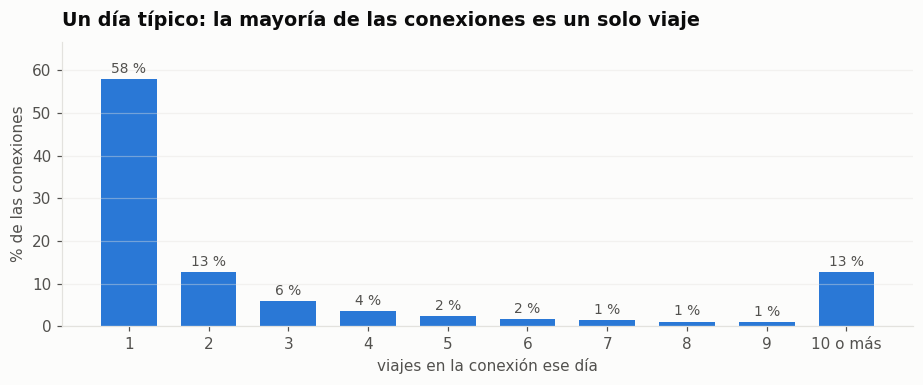

In [4]:
# Barras: % de conexiones por número de viajes
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.bar(resumen_v.index, resumen_v.porcentaje, color=AZUL, width=0.7)
for x, v in enumerate(resumen_v.porcentaje):
    ax.annotate(f"{v:.0f} %", xy=(x, v), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2)
ax.set(xlabel="viajes en la conexión ese día", ylabel="% de las conexiones",
       title="Un día típico: la mayoría de las conexiones es un solo viaje")
ax.margins(y=0.15); ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

Una conexión de un solo viaje es un celular que hizo una transición una vez: azar de
muestreo, no una conexión real de la ciudad. Por eso se trabaja sobre un conjunto fijo de
**conexiones estables**: las que tuvieron al menos 10 viajes en el 90 % de los 28 días
previos al inicio del test.

Las conexiones estables se guardan como una matriz: una fila por conexión, una columna por fecha.

In [5]:
# Carga la matriz de conexiones estables; si no hay caché, la construye el script
CACHE = Path("matriz_nucleo.parquet")
if not CACHE.exists():
    import construir_matriz_modelo
    construir_matriz_modelo.main()
M = pd.read_parquet(CACHE)

# Matriz en numpy e índices de fechas y extremos
V = M.to_numpy(dtype="float32")
fechas = list(M.columns)
ifecha = {f: i for i, f in enumerate(fechas)}
origen, destino = M.index.get_level_values(0), M.index.get_level_values(1)

# Split temporal train/test
TRAIN = ("2020-06-01", "2020-11-30")
TEST  = ("2020-12-01", "2021-03-31")
test = [f for f in fechas if pd.Timestamp(TEST[0]) <= f <= pd.Timestamp(TEST[1])]

print(f"matriz de conexiones estables: {M.shape[0]:,} conexiones x {M.shape[1]} días")
M.iloc[:5, :6]

matriz de conexiones estables: 17,651 conexiones x 332 días


2020-05-04  2020-05-05  2020-05-06  2020-05-07  2020-05-08  2020-05-09
source        target                                                                               
0900200010010 0900200010025        31.0        28.0        39.0        42.0        34.0        37.0
              090020001003A        85.0       158.0        41.0        53.0        42.0        47.0
              1510400010976        33.0        43.0        28.0        29.0        28.0        38.0
0900200010025 0900200010010        28.0        26.0        37.0        33.0        34.0        35.0
              0900200010044        18.0        34.0        26.0        37.0        14.0        15.0

## El split, con calendario

Todo lo que sigue respeta una regla: **nada de lo que se use para entrenar puede venir de
los días de test.** El tiempo se parte en dos, más una cola de historia previa que solo
sirve para que los primeros días de train tengan sus 28 días de pasado:

| Tramo | Fechas | Días | Para qué sirve |
|---|---|---|---|
| Historia previa | 4 may 2020 → 31 may 2020 | 28 | Solo para que el primer día de **train** tenga historia. No se predice |
| **Train** | 1 jun 2020 → 30 nov 2020 | 183 | Ajustar el modelo. También es donde se fijan las conexiones estables |
| **Test** | 1 dic 2020 → 31 mar 2021 | 121 | Medir. No se mira hasta el final |

**No hay set de validación, y es a propósito.** Un set de validación sirve para *elegir*
hiperparámetros sin contaminar el test. Aquí no se elige nada: la configuración del modelo
está fijada de antemano en valores conservadores y no se ajusta. Sin decisiones que tomar,
no hay nada que validar, y el split se queda en dos tramos.

Por qué train empieza en junio de 2020: antes de la pandemia la red era tan estable que no había
nada que aprender; marzo–mayo de 2020 es la llegada de la pandemia; desde junio de 2020 hay un régimen continuo. Y el test
arranca el 1 de diciembre de 2020 a propósito: deja dentro el semáforo rojo del 19 de diciembre de 2020 y
la segunda ola, que es lo interesante de medir.

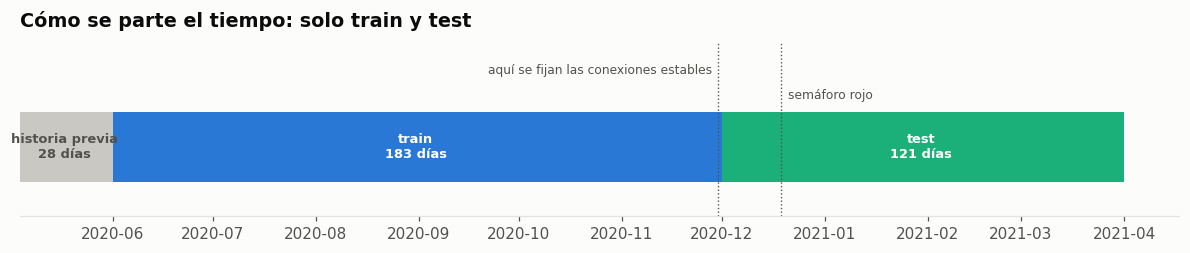

In [6]:
# Tabla de tramos del split
tramos = pd.DataFrame([
    ("historia previa", "2020-05-04", "2020-05-31", GRIS),
    ("train", TRAIN[0], TRAIN[1], AZUL),
    ("test",  TEST[0],  TEST[1],  AQUA)], columns=["tramo", "desde", "hasta", "color"])
tramos["desde"], tramos["hasta"] = pd.to_datetime(tramos.desde), pd.to_datetime(tramos.hasta)
tramos["días"] = (tramos.hasta - tramos.desde).dt.days + 1

# Línea de tiempo del split
fig, ax = plt.subplots(figsize=(11, 2.4))
for _, r in tramos.iterrows():
    ax.barh(0, r["días"], left=r.desde, color=r.color, height=0.5)
    ax.annotate(f"{r.tramo}\n{r['días']} días", xy=(r.desde + (r.hasta - r.desde) / 2, 0),
                ha="center", va="center", fontsize=8.5, fontweight="semibold",
                color="white" if r.tramo != "historia previa" else INK_2)
# Marcas de fechas clave
for f, t, dy, ha in [("2020-11-30", "aquí se fijan las conexiones estables", 0.52, "right"),
                     ("2020-12-19", "semáforo rojo", 0.34, "left")]:
    d = pd.Timestamp(f); ax.axvline(d, color=INK_2, lw=0.9, ls=":")
    ax.annotate(t, xy=(d, dy), xytext=(-4 if ha == "right" else 4, 0), textcoords="offset points",
                fontsize=8, color=INK_2, ha=ha)
ax.set(yticks=[], ylim=(-0.5, 0.75), title="Cómo se parte el tiempo: solo train y test")
for s in ["left", "top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()


## La métrica: qué es el CPC

Para comparar una matriz de viajes predicha contra la real se usa el **CPC**
(*Common Part of Commuters*), el estándar del campo:

$$
\mathrm{CPC} \;=\; \frac{2\sum_{ij}\min(\hat v_{ij},\, v_{ij})}{\sum_{ij}\hat v_{ij} + \sum_{ij} v_{ij}}
$$

Donde:

- $i$, $j$: AGEB de origen y AGEB de destino; el par $ij$ es una conexión.
- $v_{ij}$: viajes reales de $i$ a $j$ ese día.
- $\hat v_{ij}$: viajes predichos para esa misma conexión.
- $\sum_{ij}$: suma sobre todas las conexiones.
- $\min(\hat v_{ij}, v_{ij})$: la parte de la predicción que coincide con lo real.

Va de 0 a 1 y tiene una lectura directa: **la fracción de viajes que quedaron colocados
en la conexión correcta.** Un CPC de 0.85 significa que el 85 % de los viajes se
predijeron en la conexión correcta y el 15 % en la equivocada.

El $\min$ es lo que hace que funcione. Si predices 90 viajes de una AGEB de Iztapalapa a
una de Iztacalco y en realidad fueron 100, se te acreditan 90: los 10 que faltaron no
cuentan. Y si predices 20 viajes en una conexión donde no viajó nadie, el $\min$ los
tira a cero: inventar flujo se castiga igual que perderlo.

Por qué no $R^2$ ni error cuadrático: en una matriz donde unas pocas conexiones cargan
casi todo el volumen, esas métricas quedan secuestradas por un puñado de conexiones
grandes. El CPC pondera por volumen sin elevar al cuadrado.

In [7]:
# Métrica CPC
def cpc(pred, real):
    return 2 * np.minimum(pred, real).sum() / (pred.sum() + real.sum())

# Ejemplo con cuatro conexiones inventadas, para ver el mínimo operando.
ej = pd.DataFrame({"real": [100, 50, 30, 0], "predicho": [90, 60, 10, 20]},
                  index=["conexión A", "conexión B", "conexión C", "conexión D"])
ej["min"] = np.minimum(ej.real, ej.predicho)
print(f"CPC = 2 x {ej['min'].sum()} / ({ej.predicho.sum()} + {ej.real.sum()}) = "
      f"{cpc(ej.predicho.to_numpy(), ej.real.to_numpy()):.3f}")
print(f"-> {ej['min'].sum()} de {ej.real.sum()} viajes en la conexión correcta.")
ej

CPC = 2 x 150 / (180 + 180) = 0.833
-> 150 de 180 viajes en la conexión correcta.


,real,predicho,min
conexión A,100,90,90
conexión B,50,60,50
conexión C,30,10,10
conexión D,0,20,0


## Los baselines: reglas sin aprendizaje

Antes de entrenar nada, tres reglas triviales. Son el rival real: si un modelo no les
gana, no aporta.

- **Persistencia semanal:** mañana será igual que hace 7 días (mismo día de la semana).
- **Última observación:** mañana será igual que hoy.
- **Media móvil:** mañana será el promedio de los últimos 7 días.

In [8]:
# Tres reglas sin aprendizaje para el día t
def baselines(t):
    j = ifecha[t]
    return {"persistencia t-7": V[:, j-7], "última observación": V[:, j-1], "media móvil 7": V[:, j-7:j].mean(1)}

# CPC diario de cada baseline en test
B = pd.DataFrame([{k: cpc(v, V[:, ifecha[t]]) for k, v in baselines(t).items()} for t in test])
B.insert(0, "fecha", test); B["dia_semana"] = [t.dayofweek for t in test]
print("CPC medio en test:")
print(B[["persistencia t-7", "última observación", "media móvil 7"]].mean().round(4).to_string())
print("\nLa media móvil es sorprendentemente fuerte. Ese es el número a batir.\n")
B.head()

CPC medio en test:
persistencia t-7      0.7943
última observación    0.8391
media móvil 7         0.8427

La media móvil es sorprendentemente fuerte. Ese es el número a batir.



,fecha,persistencia t-7,última observación,media móvil 7,dia_semana
0,2020-12-01,0.881925,0.538179,0.897998,1
1,2020-12-02,0.879808,0.912517,0.905257,2
2,2020-12-03,0.891411,0.911901,0.896396,3
3,2020-12-04,0.860684,0.886255,0.826742,4
4,2020-12-05,0.892095,0.881319,0.893650,5


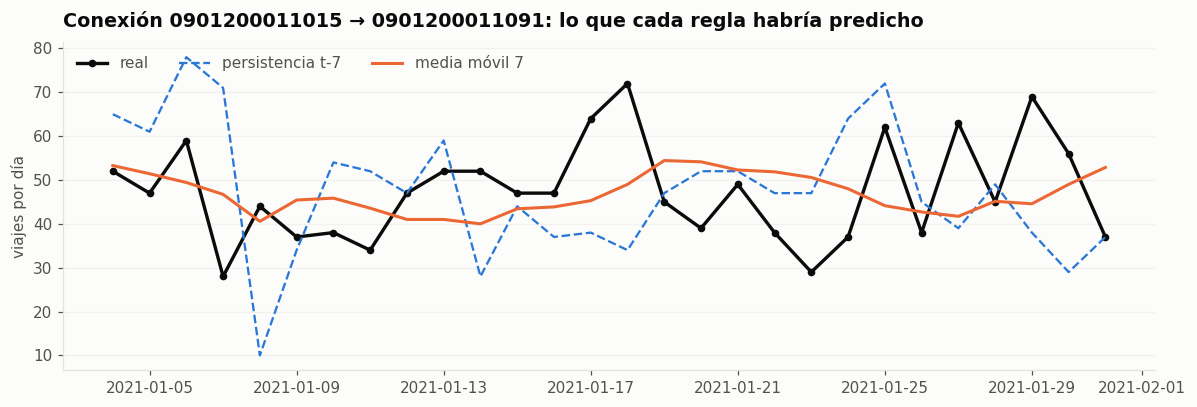

La persistencia hereda los días raros; la media móvil los diluye entre siete.



,real,persistencia t-7,media móvil 7
2021-01-04,52.0,65.0,53.285713
2021-01-05,47.0,61.0,51.428570
2021-01-06,59.0,78.0,49.428570
2021-01-07,28.0,71.0,46.714287
2021-01-08,44.0,10.0,40.571430


In [9]:
# Los tres baselines sobre UNA conexión real, durante cuatro semanas de test.
med = V[:, [ifecha[t] for t in test]].mean(1)
k = int(np.argmin(np.abs(med - 60)))                     # una conexión de ~60 viajes/día
dias = [f for f in test if pd.Timestamp("2021-01-04") <= f <= pd.Timestamp("2021-01-31")]
J = [ifecha[t] for t in dias]
ejemplo = pd.DataFrame({"real": V[k, J],
                        "persistencia t-7": [V[k, j-7] for j in J],
                        "media móvil 7": [V[k, j-7:j].mean() for j in J]}, index=dias)

# Gráfica real vs. baselines
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(ejemplo.index, ejemplo.real, color=INK, lw=2.2, marker="o", ms=4, label="real")
ax.plot(ejemplo.index, ejemplo["persistencia t-7"], color=AZUL, lw=1.5, ls="--", label="persistencia t-7")
ax.plot(ejemplo.index, ejemplo["media móvil 7"], color=NARANJA, lw=2, label="media móvil 7")
ax.set(ylabel="viajes por día", title=f"Conexión {origen[k]} → {destino[k]}: lo que cada regla habría predicho")
ax.legend(frameon=False, labelcolor=INK_2, ncol=3, loc="upper left")
ax.grid(True, axis="y", alpha=0.4); plt.tight_layout(); plt.show()

print("La persistencia hereda los días raros; la media móvil los diluye entre siete.\n")
ejemplo.head()

# 2. Un modelo entrenado

**XGBoost** con pérdida de Poisson (`count:poisson`), porque el objetivo es un conteo.
XGBoost construye árboles uno tras otro, y cada árbol corrige los errores de los
anteriores. Se entrena con el tramo de train completo, junio de 2020 a noviembre de 2020, y se mide en
test.

**La configuración está fijada, no ajustada:** 50 árboles, tasa de aprendizaje 0.1, hasta
31 hojas por árbol, peso mínimo por hoja de 500 y regularización L2 de 10. Son valores
conservadores razonables para tres millones de filas. No se probaron alternativas ni se
optimizó contra el test: por eso no hace falta un set de validación.

Un detalle que importa: no se usa *early stopping*. Para eso habría que apartar filas de
validación, y si se eligieran al azar sería una fuga (la feature `lag1` de una fila es el
objetivo de la fila del día anterior).

## Primero: qué tipo de nodo es cada AGEB en la red

Además de la historia de cada conexión, el modelo recibe **propiedades de los dos AGEBs
como nodos del grafo de movilidad**. Se calculan una sola vez sobre el grafo agregado de
octubre de 2020 y noviembre de 2020: dentro de train, así que no tocan el test.

El grafo se construye con las conexiones de al menos un viaje diario en promedio. Sin ese
filtro el grado medio es de casi 600 y medidas como el agrupamiento dejan de significar
algo: en un grafo donde casi todos están conectados con casi todos, todos los vecindarios
se ven igual de cerrados.

| Propiedad | Qué dice del AGEB |
|---|---|
| `grado_out` / `grado_in` | A cuántos AGEBs distintos manda gente y de cuántos la recibe |
| `pagerank` | Qué tan central es en la red, contando también la importancia de sus vecinos |
| `agrupamiento` | Si sus vecinos están conectados entre sí: 1 = vive en un barrio cerrado, 0 = es un puente |
| `comunidad` | A qué subregión funcional pertenece, según Louvain |

In [10]:
# Grafo de la red en train (oct-nov 2020), solo días entre semana.
dias_grafo = pd.date_range("2020-10-01", "2020-11-30")
dias_grafo = dias_grafo[dias_grafo.dayofweek < 5].strftime("%Y-%m-%d")
agg = (pd.concat([leer_dia(f) for f in dias_grafo])
       .groupby(["source", "target"], as_index=False).v.sum())
agg["v_diario"] = agg.v / len(dias_grafo)
fuerte = agg[agg.v_diario >= 1]          # sin filtro el grado medio es ~600

# Grafo dirigido, versión no dirigida y comunidades Louvain
G = nx.from_pandas_edgelist(fuerte, "source", "target", "v", create_using=nx.DiGraph)
U = G.to_undirected()
comunidades = nx.community.louvain_communities(U, weight="v", seed=1)

# Propiedades de cada AGEB como nodo
props = pd.DataFrame({
    "grado_out": pd.Series(dict(G.out_degree())),
    "grado_in": pd.Series(dict(G.in_degree())),
    "pagerank": pd.Series(nx.pagerank(G, weight="v")),
    "agrupamiento": pd.Series(nx.clustering(U)),
    "comunidad": pd.Series({n: i for i, c in enumerate(comunidades) for n in c}),
})
print(f"grafo: {G.number_of_nodes():,} AGEBs, {G.number_of_edges():,} conexiones "
      f"(de {len(agg):,} antes del filtro), {len(comunidades)} comunidades\n")
props.head()

grafo: 5,744 AGEBs, 114,018 conexiones (de 2,219,317 antes del filtro), 28 comunidades



,grado_out,grado_in,pagerank,agrupamiento,comunidad
0900200010010,11,10,0.000113,0.854545,0
0900200010025,13,13,0.000116,0.650000,0
090020001003A,16,17,0.000133,0.625731,0
0900200010044,14,16,0.000125,0.625731,0
0900200010097,19,20,0.000141,0.627706,0


## Las 24 features del modelo

**Historia de la conexión**: todas miran solo hasta el día anterior

| Feature | Qué es |
|---|---|
| `lag1` … `lag7` | Viajes de esta conexión hace 1, 2, … 7 días |
| `media7` | Promedio de viajes de los últimos 7 días |
| `media28` | Promedio de viajes de los últimos 28 días |
| `max28` | Máximo de viajes en los últimos 28 días |
| `inverso` | Viajes ayer en el sentido contrario (destino → origen) |

**Los dos AGEBs como nodos de la red**: estáticas, del grafo de oct–nov 2020

| Feature | Qué es |
|---|---|
| `grado_out_origen` | A cuántos AGEBs distintos manda gente el origen |
| `grado_in_destino` | De cuántos AGEBs distintos recibe gente el destino |
| `pagerank_origen`, `pagerank_destino` | Centralidad de cada extremo en la red |
| `agrupamiento_origen`, `agrupamiento_destino` | Si el vecindario de cada extremo está cerrado sobre sí mismo |
| `misma_comunidad` | 1 si los dos AGEBs caen en la misma subregión funcional |
| `fuerza_origen` | Viajes que salen del origen, media móvil de 7 días (dinámica) |
| `fuerza_destino` | Viajes que llegan al destino, media móvil de 7 días (dinámica) |

**La geografía y el día**

| Feature | Qué es |
|---|---|
| `km` | Distancia en línea recta entre origen y destino |
| `mismo_municipio` | 1 si ambos están en el mismo municipio |
| `dia_semana` | Día de la semana del día a predecir (0 = lunes) |
| `festivo` | 1 si el día a predecir es festivo |

In [11]:
# Distancia haversine y mismo municipio por conexión
lon, lat = np.radians(nodos.Long), np.radians(nodos.Lat)
o_lon, o_lat = lon.reindex(origen).to_numpy(), lat.reindex(origen).to_numpy()
d_lon, d_lat = lon.reindex(destino).to_numpy(), lat.reindex(destino).to_numpy()
h = np.sin((d_lat-o_lat)/2)**2 + np.cos(o_lat)*np.cos(d_lat)*np.sin((d_lon-o_lon)/2)**2
KM = np.nan_to_num(2 * 6371 * np.arcsin(np.sqrt(h)), nan=0.0).astype("float32")
MISMO_MUN = (nodos.Municipality.reindex(origen).to_numpy() == nodos.Municipality.reindex(destino).to_numpy()).astype("float32")

# Propiedades de red de cada extremo de cada conexión estable.
P_OR = props.reindex(origen).fillna(0.0)
P_DE = props.reindex(destino).fillna(0.0)
MISMA_COM = (props.comunidad.reindex(origen).to_numpy()
             == props.comunidad.reindex(destino).to_numpy()).astype("float32")

# Índice de la conexión inversa y días festivos
posicion = {par: i for i, par in enumerate(M.index)}
INVERSO = np.array([posicion.get((d, o), -1) for o, d in M.index])
FESTIVOS = {"2020-09-16", "2020-11-02", "2020-11-16", "2020-12-12", "2020-12-25", "2021-01-01", "2021-02-01", "2021-03-15"}
s_o, s_d = pd.Series(origen.to_numpy()), pd.Series(destino.to_numpy())

# Features del día t usando solo hasta t-1
def features(t):
    j = ifecha[t]; v7, v28 = V[:, j-7:j], V[:, j-28:j]; m7 = v7.mean(1)
    d = {f"lag{k}": V[:, j-k] for k in range(1, 8)}
    d.update(media7=m7, media28=v28.mean(1), max28=v28.max(1),
             inverso=np.where(INVERSO >= 0, V[INVERSO, j-1], 0.0),
             # propiedades de red, estáticas
             grado_out_origen=P_OR.grado_out.to_numpy(), grado_in_destino=P_DE.grado_in.to_numpy(),
             pagerank_origen=P_OR.pagerank.to_numpy(), pagerank_destino=P_DE.pagerank.to_numpy(),
             agrupamiento_origen=P_OR.agrupamiento.to_numpy(), agrupamiento_destino=P_DE.agrupamiento.to_numpy(),
             misma_comunidad=MISMA_COM,
             # fuerza reciente, dinámica
             fuerza_origen=pd.Series(m7).groupby(s_o).transform("sum").to_numpy(),
             fuerza_destino=pd.Series(m7).groupby(s_d).transform("sum").to_numpy(),
             km=KM, mismo_municipio=MISMO_MUN,
             dia_semana=np.full(len(V), t.dayofweek),
             festivo=np.full(len(V), float(t.strftime("%Y-%m-%d") in FESTIVOS)))
    return pd.DataFrame(d).astype("float32")

# Matriz de entrenamiento: una fila por conexión y día
dias_train = [f for f in fechas if pd.Timestamp(TRAIN[0]) <= f <= pd.Timestamp(TRAIN[1])]
X_train = pd.concat([features(t) for t in dias_train], ignore_index=True)
y_train = np.concatenate([V[:, ifecha[t]] for t in dias_train])

# Verifica que las features coincidan con el markdown
DOCUMENTADAS = ([f"lag{k}" for k in range(1, 8)] + ["media7", "media28", "max28", "inverso",
    "grado_out_origen", "grado_in_destino", "pagerank_origen", "pagerank_destino",
    "agrupamiento_origen", "agrupamiento_destino", "misma_comunidad",
    "fuerza_origen", "fuerza_destino", "km", "mismo_municipio", "dia_semana", "festivo"])
assert set(DOCUMENTADAS) == set(X_train.columns), "hay features sin documentar en el markdown"
print(f"train: {X_train.shape[0]:,} filas x {X_train.shape[1]} features (una fila por conexión y día)\n")
X_train.head()

train: 3,230,133 filas x 24 features (una fila por conexión y día)



,lag1,lag2,lag3,lag4,lag5,lag6,lag7,media7,media28,max28,...,pagerank_destino,agrupamiento_origen,agrupamiento_destino,misma_comunidad,fuerza_origen,fuerza_destino,km,mismo_municipio,dia_semana,festivo
0,31.0,31.0,20.0,32.0,24.0,25.0,33.0,28.000000,29.571428,43.0,...,0.000116,0.854545,0.650000,1.0,116.714287,98.142853,0.564263,1.0,0.0,0.0
1,42.0,38.0,50.0,50.0,55.0,42.0,29.0,43.714287,51.500000,158.0,...,0.000133,0.854545,0.625731,1.0,116.714287,159.285706,0.394650,1.0,0.0,0.0
2,38.0,22.0,56.0,55.0,53.0,51.0,40.0,45.000000,42.392857,65.0,...,0.000272,0.854545,0.306554,1.0,116.714287,419.428558,0.735152,0.0,0.0,0.0
3,35.0,26.0,13.0,30.0,20.0,24.0,31.0,25.571428,27.642857,46.0,...,0.000113,0.650000,0.854545,1.0,96.142853,116.000000,0.564263,1.0,0.0,0.0
4,19.0,17.0,35.0,24.0,16.0,38.0,24.0,24.714285,23.357143,38.0,...,0.000125,0.650000,0.625731,1.0,96.142853,164.857147,0.393887,1.0,0.0,0.0


In [12]:
# XGBoost Poisson con hiperparámetros fijos
modelo_lags = XGBRegressor(
    objective="count:poisson", n_estimators=50, learning_rate=0.1,
    tree_method="hist", grow_policy="lossguide", max_leaves=31, max_depth=0,
    min_child_weight=500, reg_lambda=10.0, random_state=0, n_jobs=-1,
    base_score=float(y_train.mean())).fit(X_train, y_train)     # el base_score automático sale mal con Poisson

# CPC del modelo en test y días entre semana
B["modelo"] = [cpc(np.maximum(modelo_lags.predict(features(t)), 0), V[:, ifecha[t]]) for t in test]
lab = B[B.dia_semana < 5]

# Comparación pareada contra cada baseline (Wilcoxon)
comparacion = pd.DataFrame([{
    "rival": rival, "CPC rival": lab[rival].mean(), "CPC modelo": lab.modelo.mean(),
    "diferencia": (lab.modelo - lab[rival]).mean(),
    "Wilcoxon p": stats.wilcoxon(lab.modelo, lab[rival]).pvalue,
} for rival in ["persistencia t-7", "última observación", "media móvil 7"]]).set_index("rival")
comparacion["significativo"] = comparacion["Wilcoxon p"] < 0.05

# Resultados y valores para el resumen final
print(f"CPC del modelo en test: {B.modelo.mean():.4f}")
print(f"Comparación pareada sobre los mismos días, entre semana (n = {len(lab)}):\n")
CPC_MEDIA7, CPC_MODELO = B["media móvil 7"].mean(), B.modelo.mean()
D_MEDIA7 = (lab.modelo - lab["media móvil 7"]).mean()
P_MEDIA7 = stats.wilcoxon(lab.modelo, lab["media móvil 7"]).pvalue
comparacion.round(4)

CPC del modelo en test: 0.8571
Comparación pareada sobre los mismos días, entre semana (n = 87):



,CPC rival,CPC modelo,diferencia,Wilcoxon p,significativo
rival,,,,,
persistencia t-7,0.7928,0.8573,0.0645,0.0000,True
última observación,0.8377,0.8573,0.0196,0.0006,True
media móvil 7,0.8468,0.8573,0.0105,0.0510,False


## Qué features usa: importancia interna del modelo

XGBoost guarda, para cada árbol, qué feature se usó en cada corte y cuánto mejoró el
ajuste. De ahí salen dos medidas:

- **Gain** (`total_gain` en XGBoost): cuánto mejoró el ajuste, sumado sobre todos los
  cortes donde se usó la feature. Se reporta como fracción del total.
- **Split** (`weight` en XGBoost): cuántas veces se usó la feature para cortar.

Las dos se miden sobre los datos de **train**: dicen qué usó el modelo para ajustarse, no
qué le sirve para predecir días que no vio. Y *split* favorece a las features continuas
con muchos valores distintos, porque tienen más cortes posibles, así que *gain* es la
que se lee primero.

In [13]:
# Importancia interna de XGBoost: gain total y número de cortes
booster = modelo_lags.get_booster()
gain = pd.Series(booster.get_score(importance_type="total_gain"))
split = pd.Series(booster.get_score(importance_type="weight"))
imp_lags = (pd.DataFrame({"gain": gain / gain.sum(), "split": split})
            .reindex(X_train.columns).fillna(0).astype({"split": int}).sort_values("gain"))
imp_lags.sort_values("gain", ascending=False).round(4).head(8)

,gain,split
media7,0.6535,140
lag1,0.1748,268
media28,0.1182,167
dia_semana,0.0147,357
lag7,0.0114,110
max28,0.0073,66
festivo,0.0039,127
lag2,0.0036,84


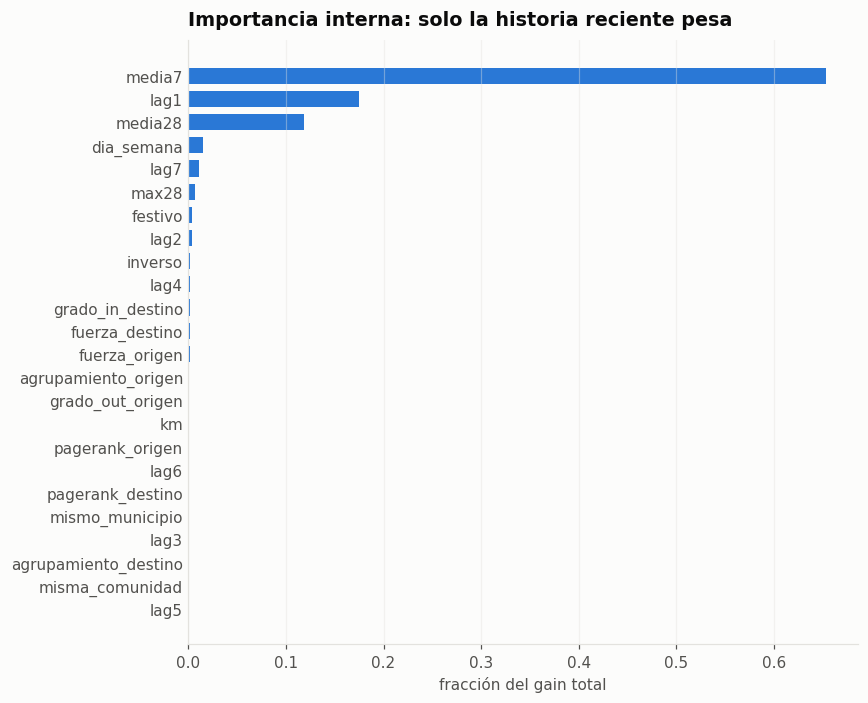

In [14]:
# Barras de importancia por gain
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(imp_lags.index, imp_lags.gain, color=AZUL, height=0.7)
ax.set(xlabel="fracción del gain total",
       title="Importancia interna: solo la historia reciente pesa")
ax.grid(True, axis="x", alpha=0.4); ax.tick_params(axis="y", length=0)
plt.tight_layout(); plt.show()

## Otra mirada: SHAP

La importancia interna dice cuánto usó el modelo cada feature al entrenar. **SHAP** reparte cada
predicción entre las features: para cada fila, cuánto empujó cada una la predicción hacia
arriba o hacia abajo respecto al promedio. Promediando su valor absoluto sobre muchas filas
sale una importancia global; el signo, fila por fila, dice la dirección.

Dos detalles. Con pérdida de Poisson el modelo trabaja en logaritmo, así que los valores
SHAP están en log(viajes): +0.1 es aproximadamente 10 % más viajes. Y se calculan sobre
5,000 filas al azar de cuatro días de test, así que sí mira datos que el modelo no vio.

In [15]:
# SHAP del modelo de pronóstico sobre filas de cuatro días de test
muestra = test[::40]
X_shap = pd.concat([features(t) for t in muestra], ignore_index=True).sample(5000, random_state=0)
sv_lags = shap.TreeExplainer(modelo_lags)(X_shap)
shap_lags = pd.DataFrame({"|SHAP| medio": np.abs(sv_lags.values).mean(0),
                          "gain (interna)": imp_lags.gain.reindex(X_shap.columns).to_numpy()},
                         index=X_shap.columns).sort_values("|SHAP| medio", ascending=False)
shap_lags.round(4).head(10)

,|SHAP| medio,gain (interna)
media7,0.2792,0.6535
lag1,0.1959,0.1748
media28,0.1823,0.1182
dia_semana,0.0619,0.0147
lag7,0.0190,0.0114
lag2,0.0126,0.0036
max28,0.0039,0.0073
festivo,0.0030,0.0039
lag4,0.0028,0.0020
inverso,0.0020,0.0020


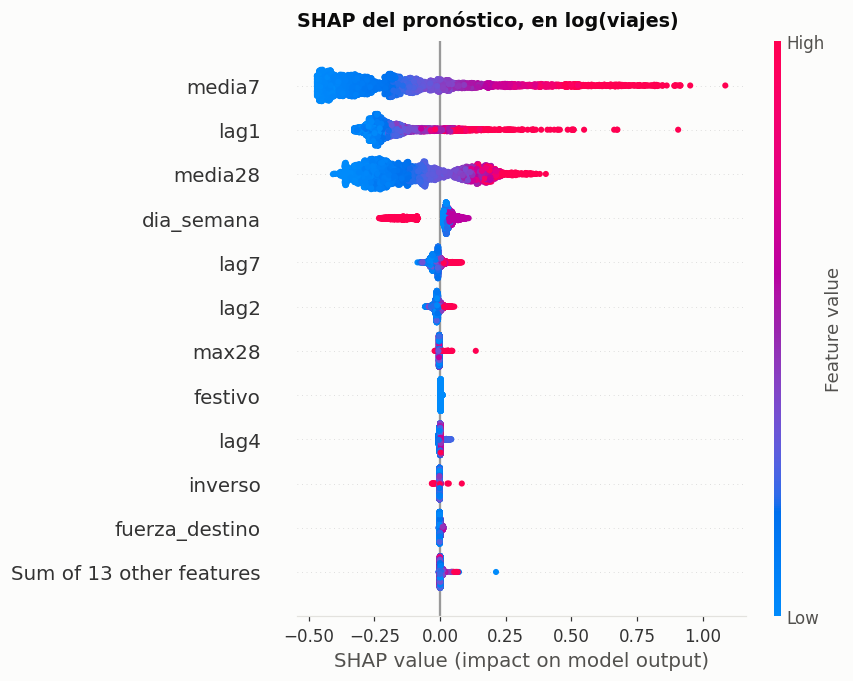

In [16]:
# Beeswarm: cada punto es una fila; el color es el valor de la feature
shap.plots.beeswarm(sv_lags, max_display=12, show=False)
plt.title("SHAP del pronóstico, en log(viajes)", loc="left")
plt.tight_layout(); plt.show()

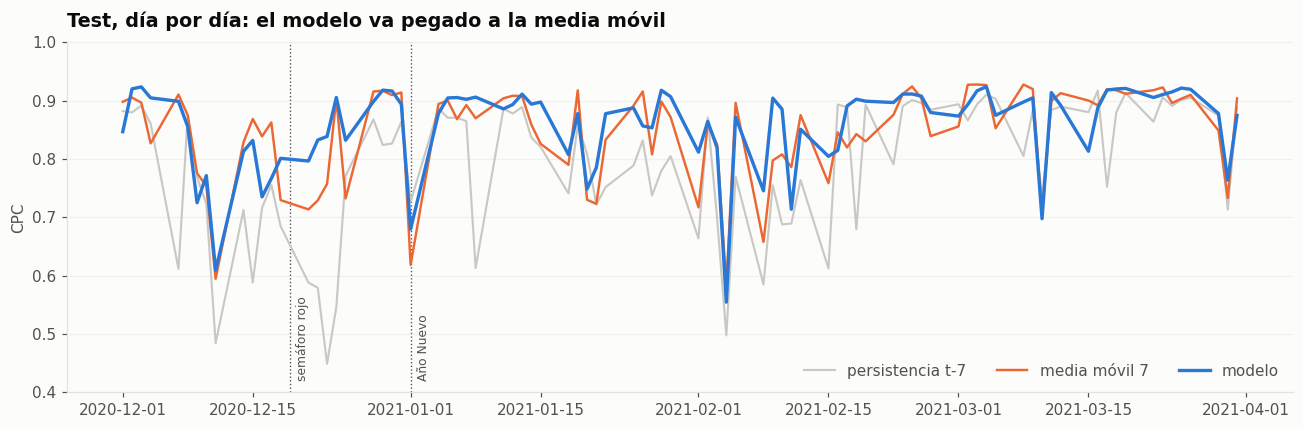

In [17]:
# CPC diario en test: modelo vs. baselines
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lab.fecha, lab["persistencia t-7"], color=GRIS, lw=1.4, label="persistencia t-7")
ax.plot(lab.fecha, lab["media móvil 7"], color=NARANJA, lw=1.6, label="media móvil 7")
ax.plot(lab.fecha, lab.modelo, color=AZUL, lw=2.2, label="modelo")
for f, t in [("2020-12-19", "semáforo rojo"), ("2021-01-01", "Año Nuevo")]:
    d = pd.Timestamp(f); ax.axvline(d, color=INK_2, lw=0.9, ls=":", zorder=0)
    ax.annotate(t, xy=(d, 0.42), xytext=(4, 0), textcoords="offset points",
                fontsize=8, color=INK_2, rotation=90, va="bottom")
ax.set(ylabel="CPC", ylim=(0.4, 1.0), title="Test, día por día: el modelo va pegado a la media móvil")
ax.legend(loc="lower right", frameon=False, labelcolor=INK_2, ncol=3)
ax.grid(True, axis="y", alpha=0.45); plt.tight_layout(); plt.show()

## Por qué el modelo no puede hacerlo mucho mejor

Piensa en adivinar cuánta gente va a pasar mañana por una calle. Lo más útil es saber
cuánta gente pasa normalmente, y eso ya lo da el promedio de la última semana.

Lo que el promedio no sabe es si mañana **toda la ciudad** va a salir más o menos de lo
normal: un cambio de semáforo, una quincena, un día de lluvia. El modelo tampoco lo sabe,
porque esa información no está en los datos. Y lo que sobra es suerte: que cada persona
decida salir o quedarse.

Por eso el modelo casi empata con el promedio. No está mal hecho: lo que falta por
adivinar simplemente no se puede adivinar con estos archivos. Para avanzar hay que
cambiar de pregunta.

# 3. Cambiar la pregunta: ¿quién pudo quedarse en casa?

Hasta aquí cada fila era *una conexión en un día* y se predecía hacia el futuro. Eso
está topado. Ahora cada fila es **un AGEB**, y lo que se predice no es el mañana sino
**cómo respondió ese lugar a la pandemia**.

## Qué es el porcentaje de los viajes, y en qué se diferencia de un viaje

- Un **viaje** es un conteo absoluto: un celular pasó de un AGEB a otro. Los viajes de un
  AGEB suben o bajan con todo lo que afecta a la ciudad, incluido cuántos celulares se
  observan ese día.
- El **porcentaje de los viajes** es relativo: la fracción de todos los viajes de la ciudad que salieron de
  ese AGEB. Si toda la ciudad baja a la mitad, los viajes de cada AGEB bajan a la mitad,
  pero su porcentaje de los viajes no cambia. Solo cambia si ese AGEB se movió más o menos que el resto.

Un ejemplo: un AGEB con 1,000 viajes en una ciudad de 1,000,000 tiene un porcentaje de los viajes de 0.1 %.
Si la ciudad cae a 500,000 y el AGEB a 500, su porcentaje de los viajes sigue en 0.1 %: bajó igual que todos.
Si el AGEB cae a 300, su porcentaje de los viajes baja a 0.06 %: se apagó más que el resto.

Para el AGEB $i$ y una ventana de tiempo $W$, su **porcentaje de los viajes** de la ciudad es

$$
s_i(W) \;=\; \frac{\sum_j v_{ij}(W)}{\sum_k \sum_j v_{kj}(W)}
$$

Donde:

- $i$: el AGEB de origen que se estudia.
- $j$: cualquier AGEB de destino.
- $k$: cualquier AGEB de origen de la ciudad; sumar sobre $k$ da el total de la ciudad.
- $W$: la ventana de tiempo (por ejemplo, octubre de 2020).
- $v_{ij}(W)$: viajes por día de $i$ a $j$, promediados en la ventana $W$.

Es decir: qué fracción de todos los viajes salientes de la ciudad salieron de $i$. El
objetivo es cuánto cambió ese porcentaje de los viajes entre antes y durante la pandemia:

$$
y_i \;=\; \log \frac{s_i(\text{octubre 2020})}{s_i(\text{febrero 2020})}
$$

Donde:

- $y_i$: el objetivo del AGEB $i$, lo que el modelo va a predecir.
- $s_i(\text{octubre 2020})$: su porcentaje de los viajes en la ventana de octubre de 2020, ya con la pandemia.
- $s_i(\text{febrero 2020})$: su porcentaje de los viajes en la ventana de febrero de 2020, antes de la pandemia.
- $\log$: logaritmo natural.

## Por qué el porcentaje de los viajes y no los viajes

Entre febrero de 2020 y octubre de 2020 **todos** los AGEBs bajaron sus viajes, por dos razones a
la vez: la gente se movió menos, y la muestra de dispositivos se encogió. Los dos
efectos son globales: multiplican a todos los AGEBs por el mismo factor $c$.

Preguntar *"¿cuántos viajes salen ahora de este AGEB de Coyoacán?"* mezcla las dos cosas
con lo que de verdad interesa. Preguntar *"¿qué parte de todos los viajes de la ciudad
sale de ese AGEB, comparada con antes?"* aísla lo que le pasó **a él** respecto a los
demás, porque en el porcentaje de los viajes el factor global se cancela:

$$
s_i' \;=\; \frac{c\,\sum_j v_{ij}}{c\,\sum_k\sum_j v_{kj}} \;=\; s_i
$$

Donde:

- $c$: el factor común que multiplica los viajes de todos los AGEBs (menos movilidad y
  menos dispositivos observados al mismo tiempo).
- $v_{ij}$, $v_{kj}$: viajes de $i$ a $j$ y de $k$ a $j$, como en la fórmula del porcentaje de los viajes.
- $s_i'$: el porcentaje de los viajes calculado con los viajes ya multiplicados por $c$.
- $s_i$: el porcentaje de los viajes original. Salen iguales porque $c$ se cancela arriba y abajo.

## Por qué el logaritmo del cociente

El porcentaje de los viajes de octubre de 2020 entre el de febrero de 2020 es un **cociente**, y los cocientes son
asimétricos: un AGEB que duplicó su porcentaje de los viajes da 2.0, y uno que lo redujo a la mitad da 0.5.
Los dos cambiaron lo mismo en magnitud, pero 2.0 está a una unidad del centro y 0.5 a
media unidad. Un modelo de mínimos cuadrados castigaría diez veces más equivocarse en
el que subió.

El logaritmo lo arregla: duplicar da $+0.69$ y reducir a la mitad da $-0.69$. Tres
consecuencias prácticas:

- **Simetría.** Subir al doble y bajar a la mitad quedan a la misma distancia del cero.
- **El cero significa algo.** $y_i = 0$ es exactamente "conservó su porcentaje de los viajes".
- **La distribución se vuelve acampanada**, que es lo que supone la pérdida cuadrática
  del regresor. Sin log queda apretada contra cero y con una cola larga a la derecha.

In [18]:
# Viajes salientes promedio por AGEB y su porcentaje de los viajes
def salidas_por_dia(fechas_ventana):
    return pd.concat([leer_dia(f).groupby("source").v.sum() for f in fechas_ventana], axis=1).fillna(0).mean(1)
def porcentaje_viajes(s):
    return s / s.sum()

VENTANAS = {"ene": pd.date_range("2020-01-13", "2020-01-31"),    # para el control negativo
            "feb": pd.date_range("2020-02-03", "2020-02-28"),    # referencia prepandemia
            "oct": pd.date_range("2020-10-05", "2020-10-30")}    # post-confinamiento
S = {k: salidas_por_dia(v.strftime("%Y-%m-%d")) for k, v in VENTANAS.items()}

# AGEBs con volumen suficiente en todas las ventanas
idx = S["feb"][S["feb"] >= 50].index      # volumen suficiente para un porcentaje de los viajes estable
for k in S: idx = idx.intersection(S[k].index)

# Objetivo: log del cambio del porcentaje de los viajes oct 2020/feb 2020
objetivo = pd.DataFrame({
    "municipio": nodos.Municipality.reindex(idx),
    "viajes_feb": S["feb"].reindex(idx), "viajes_oct": S["oct"].reindex(idx),
    "porcentaje_feb": porcentaje_viajes(S["feb"]).reindex(idx), "porcentaje_oct": porcentaje_viajes(S["oct"]).reindex(idx),
})
objetivo["cociente"] = objetivo.porcentaje_oct / objetivo.porcentaje_feb
objetivo["y"] = np.log(objetivo.cociente)
objetivo = objetivo[np.isfinite(objetivo.y)]
y_real = objetivo.y
# Control negativo: feb 2020/ene 2020, sin pandemia
y_control = np.log(porcentaje_viajes(S["feb"]).reindex(objetivo.index) / porcentaje_viajes(S["ene"]).reindex(objetivo.index))
ok = np.isfinite(y_control)
objetivo, y_real, y_control = objetivo[ok], y_real[ok], y_control[ok]
idx = objetivo.index

# Resumen
print(f"toda la ciudad: {S['feb'].sum():,.0f} viajes/día en febrero de 2020 -> {S['oct'].sum():,.0f} en octubre de 2020")
print(f"{len(idx):,} AGEBs con >= 50 viajes/día en febrero de 2020\n")
objetivo.head()

toda la ciudad: 5,974,190 viajes/día en febrero de 2020 -> 2,312,571 en octubre de 2020
5,267 AGEBs con >= 50 viajes/día en febrero de 2020



,municipio,viajes_feb,viajes_oct,porcentaje_feb,porcentaje_oct,cociente,y
source,,,,,,,
0900200010010,Azcapotzalco,400.346154,212.576923,0.000067,0.000092,1.371717,0.316063
0900200010025,Azcapotzalco,512.307692,198.192308,0.000086,0.000086,0.999401,-0.000599
090020001003A,Azcapotzalco,713.307692,302.269231,0.000119,0.000131,1.094715,0.090494
0900200010044,Azcapotzalco,626.423077,256.038462,0.000105,0.000111,1.055897,0.054390
0900200010097,Azcapotzalco,965.269231,356.115385,0.000162,0.000154,0.953073,-0.048064


In [19]:
# La simetría que da el logaritmo, en cuatro AGEBs de ejemplo.
ejemplos = objetivo.reindex(
    [objetivo.cociente.idxmin(), objetivo.cociente.sub(0.5).abs().idxmin(),
     objetivo.cociente.sub(2.0).abs().idxmin(), objetivo.cociente.idxmax()])
print("Sin log, 0.5 y 2.0 no están a la misma distancia de 1. Con log sí lo están de 0:\n")
ejemplos[["municipio", "cociente", "y"]].round(3)

Sin log, 0.5 y 2.0 no están a la misma distancia de 1. Con log sí lo están de 0:



,municipio,cociente,y
source,,,
0901000012004,Álvaro Obregón,0.085,-2.465
1306900420641,Tizayuca,0.494,-0.705
151091487,Tultitlán,2.000,0.693
1502500132159,Chalco,3.044,1.113


In [20]:
# Dos AGEBs extremos: Benito Juárez y Chalco
A  = objetivo[(objetivo.municipio == "Benito Juárez") & (objetivo.viajes_feb >= 300)].y.idxmin()
Bb = objetivo[(objetivo.municipio == "Chalco") & (objetivo.viajes_feb >= 300)].y.idxmax()
print("Los dos extremos, con volumen suficiente para ser representativos:\n")
objetivo.loc[[A, Bb]].round(4)

Los dos extremos, con volumen suficiente para ser representativos:



,municipio,viajes_feb,viajes_oct,porcentaje_feb,porcentaje_oct,cociente,y
source,,,,,,,
0901400010702,Benito Juárez,4358.5769,1127.5769,0.0007,0.0005,0.6683,-0.4030
1502500011930,Chalco,352.9231,222.6538,0.0001,0.0001,1.6298,0.4885


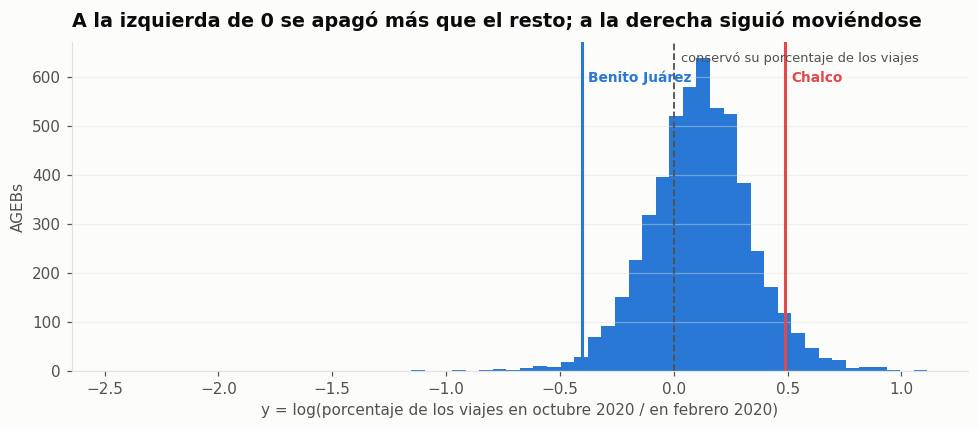

In [21]:
# Histograma del objetivo con los dos ejemplos
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_real, bins=60, color=AZUL)
ax.axvline(0, color=INK_2, lw=1.2, ls="--")
ax.annotate("conservó su porcentaje de los viajes", xy=(0, ax.get_ylim()[1]*0.97), xytext=(5, 0),
            textcoords="offset points", fontsize=8.5, color=INK_2, va="top")
for a, nom, c in [(A, "Benito Juárez", AZUL), (Bb, "Chalco", ROJO)]:
    ax.axvline(y_real[a], color=c, lw=2)
    ax.annotate(nom, xy=(y_real[a], ax.get_ylim()[1]*0.88), xytext=(4, 0), textcoords="offset points",
                color=c, fontsize=9, fontweight="semibold")
ax.set(xlabel="y = log(porcentaje de los viajes en octubre 2020 / en febrero 2020)", ylabel="AGEBs",
       title="A la izquierda de 0 se apagó más que el resto; a la derecha siguió moviéndose")
ax.grid(True, axis="y", alpha=0.4); plt.tight_layout(); plt.show()

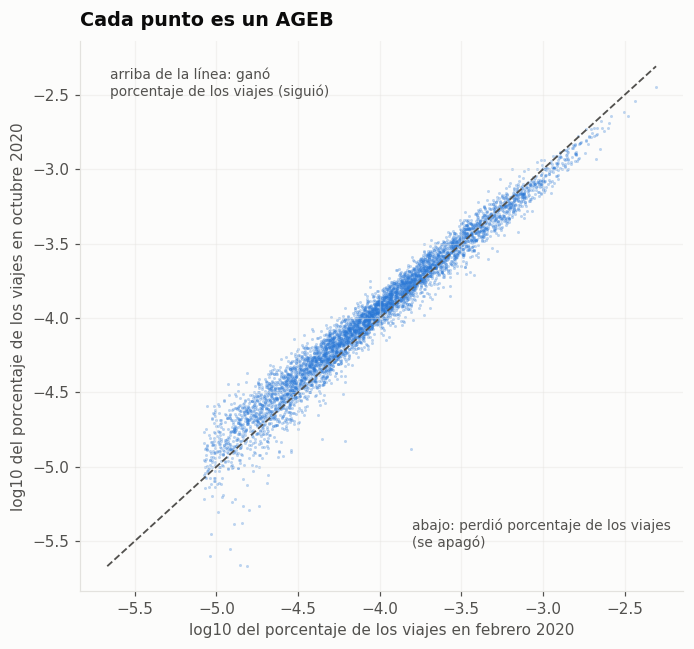

In [22]:
# Porcentaje de los viajes de febrero 2020 vs. octubre 2020 por AGEB
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(np.log10(objetivo.porcentaje_feb), np.log10(objetivo.porcentaje_oct), s=4, c=AZUL, alpha=0.3, linewidths=0)
l = [np.log10(objetivo[["porcentaje_feb", "porcentaje_oct"]].min().min()),
     np.log10(objetivo[["porcentaje_feb", "porcentaje_oct"]].max().max())]
ax.plot(l, l, color=INK_2, lw=1.2, ls="--")
ax.annotate("arriba de la línea: ganó\nporcentaje de los viajes (siguió)", xy=(0.05, 0.9), xycoords="axes fraction", fontsize=9, color=INK_2)
ax.annotate("abajo: perdió porcentaje de los viajes\n(se apagó)", xy=(0.55, 0.08), xycoords="axes fraction", fontsize=9, color=INK_2)
ax.set(xlabel="log10 del porcentaje de los viajes en febrero 2020", ylabel="log10 del porcentaje de los viajes en octubre 2020",
       title="Cada punto es un AGEB")
ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

**Lo que llevamos hasta ahora**

- Intentamos predecir cuántos viajes tendrá mañana cada conexión. El modelo casi empata
  con el promedio de la última semana: con estos datos no se puede hacer mucho mejor.
- Por eso cambiamos de pregunta: **¿cómo respondió cada AGEB a la pandemia?** Lo medimos
  con el cambio en su porcentaje de los viajes entre febrero de 2020 y octubre de 2020 ($y_i$).

**Qué sigue:** entender qué hay detrás de ese número, comprobar que es real (sección 4)
y construir el modelo que lo predice (sección 5).

## Qué hay detrás de ese número

No todos pudieron quedarse en casa: depende de si el trabajo se puede hacer a distancia
y de si se puede vivir sin ingreso diario. Y los viajes que salen de cada AGEB son de dos
tipos de gente:

| Tipo de AGEB | Quién sale de ahí | Qué nos dice $y_i$ |
|---|---|---|
| Vivienda | la gente que **vive** ahí | si sus habitantes pudieron quedarse en casa |
| Trabajo | la gente que **trabaja** ahí, de regreso a casa | si esos lugares cerraron |

## Por qué estos meses

| Ventana | Fechas | Por qué |
|---|---|---|
| **Febrero de 2020** (antes) | 3 al 28 de febrero de 2020 | Es el último mes completo de vida normal. El primer caso de COVID en México se confirmó el 28 de febrero de 2020 y el confinamiento empezó el 23 de marzo de 2020. |
| **Octubre de 2020** (con pandemia) | 5 al 30 de octubre de 2020 | Ya pasó el confinamiento duro (terminó el 30 de mayo de 2020) y la ciudad lleva meses con las mismas reglas. Todavía no llega la segunda ola ni el semáforo rojo del 19 de diciembre de 2020. Así se mide quién **siguió** en casa, no solo el primer susto. |
| **Enero de 2020** (control) | 13 al 31 de enero de 2020 | Un mes normal pegado a febrero de 2020. Empieza el 13 para dejar fuera Año Nuevo y el Día de Reyes, que cambian la movilidad. |

Además, las tres ventanas empiezan en lunes y terminan en viernes. Febrero de 2020 y
octubre de 2020 tienen exactamente los mismos días (26, de ellos 20 entre semana), así
que la comparación no depende de cuántos fines de semana cayeron en cada una.

# 4. Antes de creer nada: ¿el número es real?

Antes de construir el modelo hacemos dos pruebas. Las dos se miden con el **$R^2$**: qué
tanto del objetivo explica el modelo. 1 es perfecto, 0 es lo mismo que adivinar el
promedio, y un valor negativo es peor que el promedio.

## Prueba 1: ¿el número se repite si lo medimos otra vez?

Medimos el cambio de cada AGEB dos veces: una con la primera quincena de febrero de 2020 y de
octubre de 2020, y otra con la segunda quincena. Si las dos mediciones coinciden, el número dice
algo real del lugar. Si no coinciden, es ruido de qué celulares se conectaron esas
semanas.

¿Por qué quincenas? Son la forma más simple de partir cada ventana en dos mitades
**iguales y sin días en común**: cada quincena va de lunes a viernes de la semana
siguiente (12 días, 10 entre semana). Como las dos mitades salen del mismo mes, el lugar
no cambió entre una y otra; si el número cambia, es ruido.

Qué tanto coinciden se mide con la **correlación $r$**: un número entre −1 y 1 que dice
qué tan juntas se mueven las dos mediciones. Cerca de 1, los AGEBs que salen altos en una
también salen altos en la otra; cerca de 0, no tienen nada que ver.

Ese mismo $r$ da además una idea aproximada del **máximo $R^2$** que cualquier modelo puede alcanzar: la
parte que es ruido no se puede predecir.

## Prueba 2: ¿el método encuentra cosas donde no hay nada?

Repetimos todo exactamente igual, pero entre **enero de 2020 y febrero de 2020**, cuando todavía
no había pandemia. Ahí ningún AGEB debería cambiar de forma especial, así que el modelo
no debería poder predecir nada.

¿Por qué hace falta? Porque un modelo puede encontrar patrones falsos aunque no haya
pasado nada. Por ejemplo, un AGEB que por casualidad tuvo un febrero de 2020 alto probablemente
baje después solo por azar, y el modelo podría "predecir" esa bajada. Esos patrones
falsos aparecerían igual sin pandemia.

- Si en enero–febrero de 2020 el $R^2$ sale **cerca de 0**, el método está limpio y lo que
  encuentre en octubre de 2020 sí es la pandemia.
- Si sale **alto**, hay un truco en el método y no se le puede creer.

Esta prueba se corre en la sección 5, junto con el experimento real, con el $R^2$
*espacial*: el que se mide en zonas que el modelo no vio.

In [23]:
# Fiabilidad: objetivo con quincenas independientes
mitades = {"feb_1a": pd.date_range("2020-02-03", "2020-02-14"), "feb_2a": pd.date_range("2020-02-17", "2020-02-28"),
           "oct_1a": pd.date_range("2020-10-05", "2020-10-16"), "oct_2a": pd.date_range("2020-10-19", "2020-10-30")}
H = {k: porcentaje_viajes(salidas_por_dia(v.strftime("%Y-%m-%d"))).reindex(idx) for k, v in mitades.items()}
fiab = pd.DataFrame({"y_primeras_mitades": np.log(H["oct_1a"] / H["feb_1a"]),
                     "y_segundas_mitades": np.log(H["oct_2a"] / H["feb_2a"])}).replace([np.inf, -np.inf], np.nan).dropna()
# Correlación entre mitades y ajuste Spearman-Brown
r_fiab = fiab.corr().iloc[0, 1]

print(f"correlación entre las dos mediciones independientes: r = {r_fiab:.3f}")
print(f"fiabilidad de Spearman-Brown (ventana completa):     {2*r_fiab/(1+r_fiab):.3f}")
print(f"techo del R² alcanzable:                             ~{r_fiab:.2f}\n")
fiab.head()

correlación entre las dos mediciones independientes: r = 0.768
fiabilidad de Spearman-Brown (ventana completa):     0.869
techo del R² alcanzable:                             ~0.77



,y_primeras_mitades,y_segundas_mitades
source,,
0900200010010,0.294842,0.356457
0900200010025,0.102891,-0.130801
090020001003A,0.090717,0.093642
0900200010044,0.047323,0.043416
0900200010097,-0.059898,-0.074773


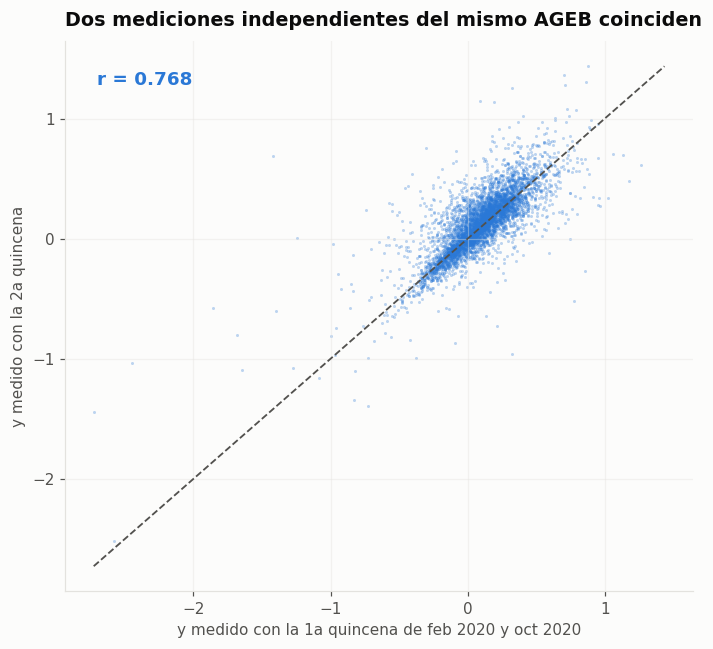

In [24]:
# Dispersión entre las dos mediciones
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(fiab.y_primeras_mitades, fiab.y_segundas_mitades, s=4, c=AZUL, alpha=0.3, linewidths=0)
l = [fiab.min().min(), fiab.max().max()]
ax.plot(l, l, color=INK_2, lw=1.2, ls="--")
ax.annotate(f"r = {r_fiab:.3f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=12,
            fontweight="semibold", color=AZUL)
ax.set(xlabel="y medido con la 1a quincena de feb 2020 y oct 2020", ylabel="y medido con la 2a quincena",
       title="Dos mediciones independientes del mismo AGEB coinciden")
ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

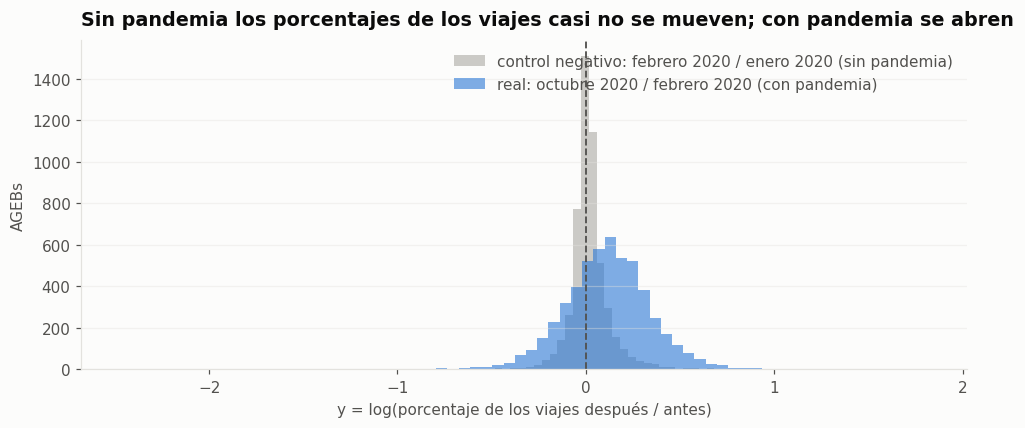

       real (oct 2020/feb 2020)  control negativo (feb 2020/ene 2020)
count                  5267.000                              5267.000
mean                      0.112                                 0.023
std                       0.239                                 0.116
min                      -2.465                                -0.693
25%                      -0.024                                -0.027
50%                       0.117                                 0.010
75%                       0.255                                 0.055
max                       1.113                                 1.808


In [25]:
# Histogramas: real vs. control negativo
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_control, bins=60, color=GRIS, alpha=0.95, label="control negativo: febrero 2020 / enero 2020 (sin pandemia)")
ax.hist(y_real, bins=60, color=AZUL, alpha=0.6, label="real: octubre 2020 / febrero 2020 (con pandemia)")
ax.axvline(0, color=INK_2, lw=1.2, ls="--")
ax.set(xlabel="y = log(porcentaje de los viajes después / antes)", ylabel="AGEBs",
       title="Sin pandemia los porcentajes de los viajes casi no se mueven; con pandemia se abren")
ax.legend(frameon=False, labelcolor=INK_2); ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

print(pd.DataFrame({"real (oct 2020/feb 2020)": y_real.describe(), "control negativo (feb 2020/ene 2020)": y_control.describe()}).round(3).to_string())

# 5. El experimento

## Las features: el ratio fin de semana / entre semana y la posición de un lugar en la red

Las features se calculan **solo con la red de febrero de 2020**, antes de que nadie
supiera lo que venía. La pregunta es: *¿lo que un lugar era en febrero de 2020 predice lo que le
pasó en octubre de 2020?*

La feature central es el **ratio fin de semana / entre semana**:

$$
\text{ratio}_i \;=\; \frac{\text{viajes por día en fin de semana}}{\text{viajes por día entre semana}}
$$

Donde:

- $i$: el AGEB.
- Numerador: viajes promedio por día en sábado y domingo, en febrero de 2020.
- Denominador: viajes promedio por día de lunes a viernes, en febrero de 2020.
- Se calcula dos veces: con los viajes que **salen** del AGEB y con los que **llegan**.

Compara dos AGEBs de los datos. Uno de oficinas en Miguel Hidalgo recibe miles de
personas de lunes a viernes y queda casi vacío el sábado: su ratio de entrada es bajo.
Uno de vivienda en Chalco manda gente todos los días, sábado incluido: su ratio ronda 1.

Ese cociente, calculado con nada más que la red, ya separa un lugar de trabajo de un
lugar donde se vive: sin censo, sin catastro, sin uso de suelo. Y esa es justo la
distinción que separa a quien pudo teletrabajar de quien no.

A ese ratio se le suman las **propiedades del AGEB como nodo del grafo**: de cuántos
lugares distintos recibe gente, qué tan central es, y si su vecindario está cerrado sobre
sí mismo o funciona como puente. Un centro de empleo no solo tiene un ratio distinto: también
recibe gente de muchísimos orígenes dispersos, cosa que una zona de vivienda no hace.

## Las 20 features del modelo

**Ratio fin de semana / entre semana**: es lo que revela si el lugar es de trabajo o de vivienda

| Feature | Qué es |
|---|---|
| `ratio_finde_salida` | Salidas por día en fin de semana ÷ entre semana. Bajo = oficinas |
| `ratio_finde_entrada` | Llegadas por día en fin de semana ÷ entre semana. Bajo = recibe trabajadores |

**Volumen**

| Feature | Qué es |
|---|---|
| `log_salida_lab` | Cuántos viajes salen del AGEB entre semana (en logaritmo) |
| `log_entrada_lab` | Cuántos viajes llegan al AGEB entre semana (en logaritmo) |
| `atraccion` | (llegadas − salidas) ÷ (llegadas + salidas): si atrae o emite gente |

**El AGEB como nodo de la red**: del grafo de febrero de 2020, con el mismo filtro de al menos
un viaje diario que se usó antes

| Feature | Qué es |
|---|---|
| `grado_in` | De cuántos AGEBs distintos recibe gente |
| `pagerank` | Qué tan central es en la red, contando la importancia de sus vecinos |
| `agrupamiento` | Si sus vecinos están conectados entre sí: 1 = barrio cerrado, 0 = puente |
| `tam_comunidad` | Cuántos AGEBs tiene la subregión funcional a la que pertenece |

**Alcance espacial**: qué tan lejos viaja su gente

| Feature | Qué es |
|---|---|
| `km_medio` | Distancia media de sus viajes, ponderada por viajes |
| `frac_2km` | Fracción de sus viajes de 2 km o menos (movilidad de barrio) |
| `frac_10km` | Fracción de sus viajes que superan 10 km (viajes largos) |
| `km_a_hub` | Distancia al centro de empleo más cercano (de los 20 que más gente reciben) |

**Diversidad de destinos**

| Feature | Qué es |
|---|---|
| `n_destinos` | A cuántos AGEBs distintos manda viajes |
| `top3_share` | Fracción de sus viajes que va a sus 3 destinos principales |
| `frac_intra_mun` | Fracción de sus viajes que se queda en el mismo municipio |

**Contexto**

| Feature | Qué es |
|---|---|
| `lat`, `lon` | Coordenadas del AGEB (`lon` positiva hacia el oriente) |
| `log_pob` | Población del municipio al que pertenece (en logaritmo) |
| `urbana` | 1 si es AGEB urbana, 0 si rural |

In [26]:
# Viajes de febrero de 2020, entre semana y fin de semana
feb = VENTANAS["feb"]
lab_f = pd.concat([leer_dia(f) for f in feb[feb.dayofweek < 5].strftime("%Y-%m-%d")]).groupby(["source", "target"], as_index=False).v.sum()
fin_f = pd.concat([leer_dia(f) for f in feb[feb.dayofweek >= 5].strftime("%Y-%m-%d")]).groupby(["source", "target"], as_index=False).v.sum()
n_lab, n_fin = (feb.dayofweek < 5).sum(), (feb.dayofweek >= 5).sum()
# Distancia de cada viaje entre semana
a1, a2 = lat.reindex(lab_f.source).to_numpy(), lat.reindex(lab_f.target).to_numpy()
b1, b2 = lon.reindex(lab_f.source).to_numpy(), lon.reindex(lab_f.target).to_numpy()
lab_f["km"] = 2*6371*np.arcsin(np.sqrt(np.sin((a2-a1)/2)**2 + np.cos(a1)*np.cos(a2)*np.sin((b2-b1)/2)**2))
# Salidas y llegadas por AGEB
mu = nodos.Municipality; g = lab_f.groupby("source")
sal_lab, ent_lab = g.v.sum(), lab_f.groupby("target").v.sum()
sal_fin, ent_fin = fin_f.groupby("source").v.sum(), fin_f.groupby("target").v.sum()
ent = ent_lab.reindex(sal_lab.index).fillna(0)

# Features de ratio fin de semana / entre semana, volumen, alcance y diversidad
X = pd.DataFrame({
    "ratio_finde_salida":  (sal_fin.reindex(sal_lab.index).fillna(0)/n_fin) / (sal_lab/n_lab),
    "ratio_finde_entrada": (ent_fin.reindex(sal_lab.index).fillna(0)/n_fin) / (ent/n_lab + 1),
    "log_salida_lab": np.log1p(sal_lab), "log_entrada_lab": np.log1p(ent),
    "atraccion": (ent - sal_lab) / (ent + sal_lab),
    "km_medio":  g.apply(lambda d: np.average(d.km.fillna(0), weights=d.v), include_groups=False),
    "frac_2km":  g.apply(lambda d: d.v[d.km <= 2].sum() / d.v.sum(), include_groups=False),
    "frac_10km": g.apply(lambda d: d.v[d.km > 10].sum() / d.v.sum(), include_groups=False),
    "n_destinos": g.size(),
    "top3_share": g.apply(lambda d: d.v.nlargest(3).sum() / d.v.sum(), include_groups=False),
    "frac_intra_mun": g.apply(lambda d: d.v[d.target.map(mu).values == mu.get(d.name)].sum() / d.v.sum(), include_groups=False),
})
# El AGEB como nodo de la red de febrero de 2020, con el mismo filtro de antes.
fuerte_feb = lab_f[lab_f.v / n_lab >= 1]
G_feb = nx.from_pandas_edgelist(fuerte_feb, "source", "target", "v", create_using=nx.DiGraph)
U_feb = G_feb.to_undirected()
com_feb = nx.community.louvain_communities(U_feb, weight="v", seed=1)
tam_com = pd.Series({n: len(c) for c in com_feb for n in c})
X["grado_in"] = pd.Series(dict(G_feb.in_degree())).reindex(X.index).fillna(0)
X["pagerank"] = pd.Series(nx.pagerank(G_feb, weight="v")).reindex(X.index).fillna(0)
X["agrupamiento"] = pd.Series(nx.clustering(U_feb)).reindex(X.index).fillna(0)
X["tam_comunidad"] = tam_com.reindex(X.index).fillna(0)
print(f"grafo de febrero de 2020: {G_feb.number_of_nodes():,} AGEBs, {G_feb.number_of_edges():,} "
      f"conexiones, {len(com_feb)} comunidades")

# Distancia al centro de empleo más cercano
hubs = ent_lab.nlargest(20).index
hl, ho = lat.reindex(hubs).to_numpy(), lon.reindex(hubs).to_numpy()
al, ao = lat.reindex(X.index).to_numpy(), lon.reindex(X.index).to_numpy()
X["km_a_hub"] = [np.nanmin(2*6371*np.arcsin(np.sqrt(np.sin((hl-a)/2)**2 + np.cos(a)*np.cos(hl)*np.sin((ho-b)/2)**2))) for a, b in zip(al, ao)]
# Contexto: coordenadas, población y tipo
X["lat"], X["lon"] = nodos.Lat.reindex(X.index), nodos.Long.reindex(X.index)
X["log_pob"] = np.log1p(nodos.Pob_MUN.reindex(X.index))
X["urbana"] = (nodos.Type.reindex(X.index) == "Urbana").astype(float)
# Alinea features con el objetivo
X = X.reindex(idx).dropna()
y_real, y_control = y_real.reindex(X.index), y_control.reindex(X.index)

# Verifica que las features coincidan con el markdown
DOCUMENTADAS_PERFIL = ["ratio_finde_salida", "ratio_finde_entrada", "log_salida_lab", "log_entrada_lab",
    "atraccion", "km_medio", "frac_2km", "frac_10km", "km_a_hub", "n_destinos", "top3_share",
    "frac_intra_mun", "grado_in", "pagerank", "agrupamiento", "tam_comunidad",
    "lat", "lon", "log_pob", "urbana"]
assert set(DOCUMENTADAS_PERFIL) == set(X.columns), "hay features sin documentar en el markdown"
print(f"{X.shape[0]:,} AGEBs x {X.shape[1]} features, todas calculadas con febrero 2020\n")
X.head()

grafo de febrero de 2020: 5,797 AGEBs, 210,414 conexiones, 20 comunidades
5,265 AGEBs x 20 features, todas calculadas con febrero 2020



,ratio_finde_salida,ratio_finde_entrada,log_salida_lab,log_entrada_lab,atraccion,km_medio,frac_2km,frac_10km,n_destinos,top3_share,frac_intra_mun,grado_in,pagerank,agrupamiento,tam_comunidad,km_a_hub,lat,lon,log_pob,urbana
source,,,,,,,,,,,,,,,,,,,,
0900200010010,0.899516,0.893516,9.011646,9.022685,0.005520,1.501323,0.909235,0.040625,357,0.589362,0.554959,19.0,0.000082,0.831579,83.0,4.490591,19.513012,-99.205966,12.976658,1.0
0900200010025,0.582701,0.587373,9.336003,9.336797,0.000397,1.604288,0.895308,0.033251,551,0.514288,0.736550,28.0,0.000103,0.719212,83.0,4.923451,19.512498,-99.200609,12.976658,1.0
090020001003A,0.856433,0.849997,9.599405,9.597913,-0.000746,1.118253,0.924771,0.017824,438,0.539004,0.530261,30.0,0.000120,0.643939,83.0,4.129470,19.509966,-99.207899,12.976658,1.0
0900200010044,0.757850,0.755255,9.493336,9.495594,0.001129,1.036033,0.935268,0.014017,371,0.512660,0.875207,29.0,0.000112,0.655242,83.0,4.553168,19.509742,-99.202970,12.976658,1.0
0900200010097,0.725503,0.724378,9.933629,9.935325,0.000848,1.029977,0.942700,0.008927,424,0.484838,0.777158,33.0,0.000146,0.583215,83.0,4.028712,19.506797,-99.206947,12.976658,1.0


In [27]:
# El ratio fin de semana / entre semana de los dos AGEBs de ejemplo, uno de oficinas y uno de vivienda.
print("Un AGEB de oficinas contra uno de vivienda, con su ratio fin de semana / entre semana y otras features:\n")
X.loc[[A, Bb], ["ratio_finde_salida", "ratio_finde_entrada", "log_salida_lab", "pagerank", "agrupamiento"]].assign(
    municipio=nodos.Municipality.reindex([A, Bb]), y=y_real.reindex([A, Bb])).round(3)

Un AGEB de oficinas contra uno de vivienda, con su ratio fin de semana / entre semana y otras features:



,ratio_finde_salida,ratio_finde_entrada,log_salida_lab,pagerank,agrupamiento,municipio,y
source,,,,,,,
0901400010702,0.519,0.517,11.493,0.0,0.487,Benito Juárez,-0.403
1502500011930,0.815,0.803,8.906,0.0,0.377,Chalco,0.488


## El modelo

**Qué predice.** Para cada AGEB, el modelo recibe sus 20 features, calculadas con febrero
de 2020, y predice $y_i$: cuánto cambió su porcentaje de los viajes entre febrero de 2020
y octubre de 2020. Un valor negativo quiere decir que se apagó más que el resto; uno
positivo, que siguió moviéndose.

**Qué modelo es.** **XGBoost**, el mismo tipo de modelo que en la sección 2: muchos
árboles de decisión chicos, construidos uno tras otro, donde cada árbol corrige los
errores de los anteriores. Aquí la pérdida es el **error cuadrático** y no Poisson,
porque $y_i$ no es un conteo sino un logaritmo que puede ser negativo.

**La configuración está fijada, no ajustada:** 300 árboles, tasa de aprendizaje 0.05,
hasta 15 hojas por árbol y al menos 40 AGEBs por hoja. Son valores conservadores para
unos 5,000 AGEBs, y no se eligieron mirando el resultado.

## El test tiene que ser espacial, no aleatorio

Aquí el split es distinto al de la primera parte: **por lugar, no por tiempo**. Ya no hay
"futuro" que retener. El tiempo queda *adentro* de cada fila: febrero de 2020 construye las
features, octubre de 2020 construye el objetivo. Lo que se retiene para test son **AGEBs**: el
modelo aprende en unos lugares y se evalúa en lugares que nunca vio. Falta decidir cómo
se eligen esos lugares.

### Validación cruzada: qué es un pliegue

Con un solo reparto entre train y test, el resultado depende de la suerte: de qué AGEBs
cayeron en test. La **validación cruzada** lo evita repitiendo la prueba varias veces:

1. Se parten los AGEBs en 5 grupos. Cada grupo es un **pliegue**.
2. Se aparta un pliegue como test y se entrena el modelo con los otros 4.
3. Se mide el $R^2$ en el pliegue apartado.
4. Se repite 5 veces, apartando cada vez un pliegue distinto.
5. Se promedian los 5 valores de $R^2$.

Así cada AGEB queda en test exactamente una vez, y el modelo nunca se evalúa con un AGEB
que usó para entrenar.

Lo que cambia entre las dos versiones es **cómo se arman los pliegues**, y eso da
números muy distintos:

**$R^2$ aleatorio**: se revuelven los 5,265 AGEBs y se reparten al azar en los cinco
pliegues. El problema es que los AGEBs vecinos se parecen: si un AGEB de Iztapalapa cae
en test, es casi seguro que varios de sus vecinos inmediatos quedaron en train. El modelo
no necesita entender nada: le basta reconocer la zona y copiar el valor de al lado. Ese
$R^2$ mide qué tan bien copia del vecindario.

**$R^2$ espacial**: primero se agrupan los AGEBs en 20 bloques geográficos (AGEBs
cercanos entre sí). Luego cada pliegue se arma con **cuatro bloques completos** (20 ÷ 5),
unas 1,100 AGEBs contiguas. Si Iztapalapa entera está en
test, no hay vecinos de quienes copiar: el modelo tiene que haber aprendido la relación
*ratio fin de semana / entre semana → respuesta a la pandemia* y aplicarla a una zona que nunca vio. Ese es el
número honesto.

¿Por qué 20 bloques? Es un equilibrio. Con menos, cada pliegue sería una sola región
grande y muy distinta al resto, y el resultado saldría demasiado pesimista. Con más, los
bloques serían tan chicos que muchos AGEBs de test tendrían vecinos pegados en train, y
el modelo podría volver a copiar.

Qué tanto importa la diferencia depende de cuánto se parezcan los vecinos, y eso se puede
medir: la correlación entre el objetivo de un AGEB y el promedio de sus 20 vecinos más
cercanos.

$$
\rho_{\text{esp}} \;=\; \mathrm{corr}\!\left(y_i,\; \tfrac{1}{k}\textstyle\sum_{j \in N_k(i)} y_j\right)
$$

Donde:

- $y_i$: el objetivo del AGEB $i$.
- $N_k(i)$: los $k$ AGEBs geográficamente más cercanos a $i$, sin contar a $i$.
- $k$: el número de vecinos; aquí 20.
- $\tfrac{1}{k}\sum_{j \in N_k(i)} y_j$: el promedio del objetivo en esos vecinos.
- $\mathrm{corr}$: la correlación de Pearson, calculada sobre todos los AGEBs.
- $\rho_{\text{esp}}$: la autocorrelación espacial. Cerca de 1, los vecinos se parecen mucho;
  cerca de 0, no se parecen.

Se reportan **los dos**. La diferencia entre ellos es en sí un resultado: dice cuánto del
poder predictivo era pura proximidad. Y el control negativo se corre con el mismo montaje.

In [28]:
# Autocorrelación espacial con 20 vecinos
xy = X[["lon", "lat"]].to_numpy()
_, vec = cKDTree(xy).query(xy, k=21)
rho_esp = np.corrcoef(y_real.to_numpy(), y_real.to_numpy()[vec[:, 1:]].mean(1))[0, 1]
print(f"autocorrelación espacial del objetivo (20 vecinos más cercanos): {rho_esp:+.3f}")
print("-> los vecinos se parecen mucho, así que el reparto aleatorio va a inflar el R².\n")

# 20 bloques geográficos con KMeans
bloques = KMeans(20, n_init=5, random_state=0).fit_predict(xy)
tam_bloques = pd.Series(bloques).value_counts().sort_index().rename("AGEBs")
tam_bloques.index.name = "bloque"
print(f"tamaño de los 20 bloques: mediana {tam_bloques.median():.0f} AGEBs, "
      f"rango {tam_bloques.min()}-{tam_bloques.max()}")
print(f"cada pliegue retiene 4 bloques ≈ {4*tam_bloques.median():.0f} AGEBs contiguas\n")
tam_bloques.head()

autocorrelación espacial del objetivo (20 vecinos más cercanos): +0.577
-> los vecinos se parecen mucho, así que el reparto aleatorio va a inflar el R².

tamaño de los 20 bloques: mediana 278 AGEBs, rango 61-414
cada pliegue retiene 4 bloques ≈ 1110 AGEBs contiguas



bloque
0    403
1    360
2    414
3     99
4    258
Name: AGEBs, dtype: int64

In [29]:
# Validación cruzada aleatoria y espacial por bloques
cv_aleatoria, cv_espacial = KFold(5, shuffle=True, random_state=0), GroupKFold(5)
# XGBoost con error cuadrático y configuración fija
def modelo():
    return XGBRegressor(objective="reg:squarederror", n_estimators=300, learning_rate=0.05,
                        tree_method="hist", grow_policy="lossguide", max_leaves=15, max_depth=0,
                        min_child_weight=40, random_state=0, n_jobs=-1)
# R² para real/control y básicas/perfil completo
basicas = ["log_salida_lab", "lat", "lon", "log_pob", "urbana"]
res = []
for objetivo_nom, yy in [("real (oct 2020/feb 2020)", y_real), ("control negativo (feb 2020/ene 2020)", y_control)]:
    for cuales, cols in [("básicas", basicas), ("perfil completo", list(X.columns))]:
        esp = cross_val_score(modelo(), X[cols], yy, cv=cv_espacial, groups=bloques, scoring="r2")
        res.append({"objetivo": objetivo_nom, "features": cuales,
                    "R² aleatorio": cross_val_score(modelo(), X[cols], yy, cv=cv_aleatoria, scoring="r2").mean(),
                    "R² espacial": esp.mean(), "R² espacial (desv. est.)": esp.std()})
R2 = pd.DataFrame(res).set_index(["objetivo", "features"])
R2.round(3)

R² aleatorio  R² espacial  R² espacial (desv. est.)
objetivo                             features                                                            
real (oct 2020/feb 2020)             básicas                 0.308        0.075                     0.150
                                     perfil completo         0.375        0.212                     0.140
control negativo (feb 2020/ene 2020) básicas                 0.092       -0.128                     0.120
                                     perfil completo         0.129       -0.024                     0.148

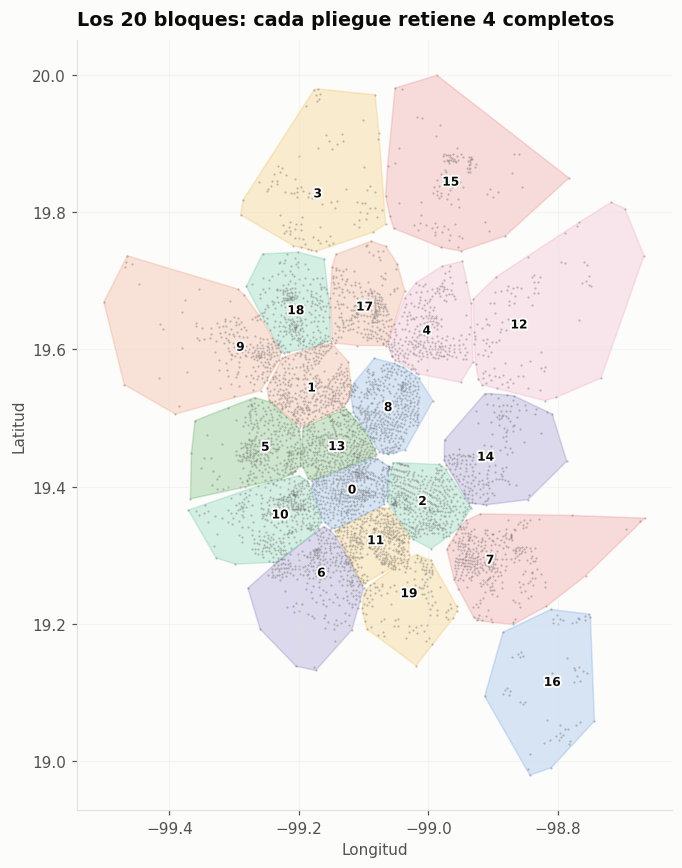

In [30]:
# Mapa de los 20 bloques
ASPECT = 1 / np.cos(np.radians(X.lat.mean()))
fig, ax = plt.subplots(figsize=(8, 8))
for b in range(20):
    pts = xy[bloques == b]
    if len(pts) >= 3:
        hull = ConvexHull(pts)
        ax.add_patch(Polygon(pts[hull.vertices], closed=True, facecolor=CATEG[b % 8],
                             alpha=0.18, edgecolor=CATEG[b % 8], lw=1))
    ax.annotate(str(b), xy=pts.mean(0), ha="center", va="center", fontsize=8,
                fontweight="bold", color=INK, path_effects=[pe.withStroke(linewidth=2.5, foreground=SURFACE)])
# Puntos de los AGEBs
ax.scatter(xy[:, 0], xy[:, 1], s=2, c=INK_2, alpha=0.35, linewidths=0)
ax.set_aspect(ASPECT)
ax.set(xlabel="Longitud", ylabel="Latitud",
       title="Los 20 bloques: cada pliegue retiene 4 completos")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

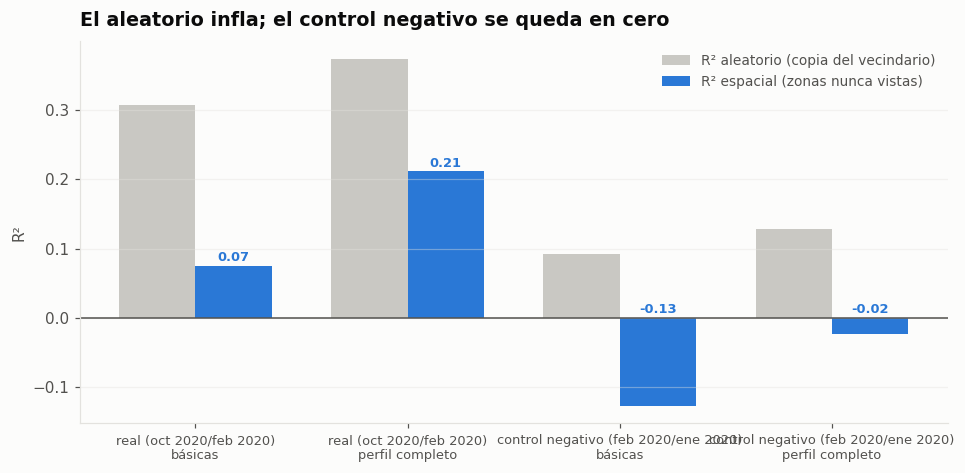

In [31]:
# Barras: R² aleatorio vs. espacial
tabla = R2.reset_index()
etiquetas = [f"{o}\n{f}" for o, f in zip(tabla.objetivo, tabla.features)]
xpos = np.arange(len(tabla)); w = 0.36
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(xpos - w/2, tabla["R² aleatorio"], w, color=GRIS, label="R² aleatorio (copia del vecindario)")
ax.bar(xpos + w/2, tabla["R² espacial"], w, color=AZUL, label="R² espacial (zonas nunca vistas)")
ax.axhline(0, color=INK_2, lw=1)
for i, re_ in enumerate(tabla["R² espacial"]):
    ax.annotate(f"{re_:.2f}", xy=(i + w/2, max(re_, 0)), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=8.5, color=AZUL, fontweight="semibold")
ax.set_xticks(xpos, etiquetas, fontsize=8.5)
ax.set(ylabel="R²", title="El aleatorio infla; el control negativo se queda en cero")
ax.legend(frameon=False, labelcolor=INK_2, fontsize=9); ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

Lectura de la tabla:

- **Aleatorio contra espacial.** El aleatorio siempre sale mayor, y esa diferencia es
  proximidad, no aprendizaje. El espacial es el número que se reporta.
- **Básicas contra perfil completo.** El ratio fin de semana / entre semana y las propiedades de red
  multiplican por más de dos el $R^2$ espacial, con datos que ya estaban en la red y sin
  descargar nada.
- **Real contra control negativo.** Mismas features, mismo modelo, mismo montaje, sobre dos meses
  tranquilos: el $R^2$ espacial se va a cero o por debajo. El método no inventa señal; lo
  que encuentra en octubre de 2020 es la pandemia.

## Qué features pesan: importancia interna del modelo

Igual que en la sección 2, se usa la importancia interna de XGBoost:

- **Gain:** cuánto mejoró el ajuste cada feature, sumado sobre todos los cortes donde se
  usó. Se reporta como fracción del total.
- **Split:** cuántas veces se usó la feature para cortar.

Se calcula con cada uno de los 5 modelos de la validación cruzada espacial (cada uno
entrenado con 16 bloques) y se promedia. Esta importancia se mide sobre los datos de
entrenamiento: dice qué usó el modelo para ajustarse, no qué le sirve en zonas que no
vio. Por eso después se complementa con SHAP, que sí se calcula en zonas no vistas.

In [32]:
# Importancia interna de XGBoost, promediada sobre los 5 modelos de la validación espacial
gain, split = pd.Series(0.0, index=X.columns), pd.Series(0.0, index=X.columns)
for tr, te in cv_espacial.split(X, y_real, bloques):
    b = modelo().fit(X.iloc[tr], y_real.iloc[tr]).get_booster()
    g = pd.Series(b.get_score(importance_type="total_gain")).reindex(X.columns).fillna(0)
    gain += g / g.sum() / 5
    split += pd.Series(b.get_score(importance_type="weight")).reindex(X.columns).fillna(0) / 5
imp = gain

# Importancia junto a la dirección del efecto
importancia = pd.DataFrame({"gain": gain, "split": split.round().astype(int),
                            "dirección (Spearman)": X.corrwith(y_real, method="spearman")}
                           ).sort_values("gain", ascending=False)
print("Dirección positiva = a más valor de la feature, el AGEB siguió moviéndose.\n")
importancia.round(3).head(8)

Dirección positiva = a más valor de la feature, el AGEB siguió moviéndose.



,gain,split,dirección (Spearman)
ratio_finde_salida,0.132,202,0.429
ratio_finde_entrada,0.123,214,0.427
frac_10km,0.097,207,0.383
km_a_hub,0.079,262,0.444
lat,0.064,339,0.120
log_salida_lab,0.056,244,-0.424
lon,0.053,353,0.236
log_pob,0.043,195,-0.121


### Cómo leer la gráfica

Cada barra tiene dos datos distintos:

- **El largo** es la importancia: cuánto usó el modelo esa feature.
- **El número y el color** son la **dirección**, medida con la correlación de Spearman
  entre la feature y $y_i$ en todos los AGEBs:
  - **Positivo (azul):** los AGEBs con valores más altos de esa feature tendieron a
    **seguir moviéndose**. Por ejemplo, `ratio_finde_salida` (+0.43): los lugares con
    mucha actividad en fin de semana, de vivienda, siguieron moviéndose.
  - **Negativo (naranja):** los AGEBs con valores más altos tendieron a **apagarse**. Por
    ejemplo, `grado_in` (−0.36): los lugares que reciben gente de muchos orígenes, de
    trabajo, se apagaron.
  - **Cerca de 0:** la feature, por sí sola, no muestra una dirección clara.

Spearman solo mira el **orden** de los valores, no los valores exactos, así que unos pocos
AGEBs extremos no lo distorsionan.

Dos cuidados: el color solo depende del signo, así que una feature con +0.01 sale del
mismo color que una con +0.43; hay que fijarse en el número. Y es la relación de cada
feature **por separado**; SHAP, más abajo, la mide dentro del modelo, considerando las
demás.

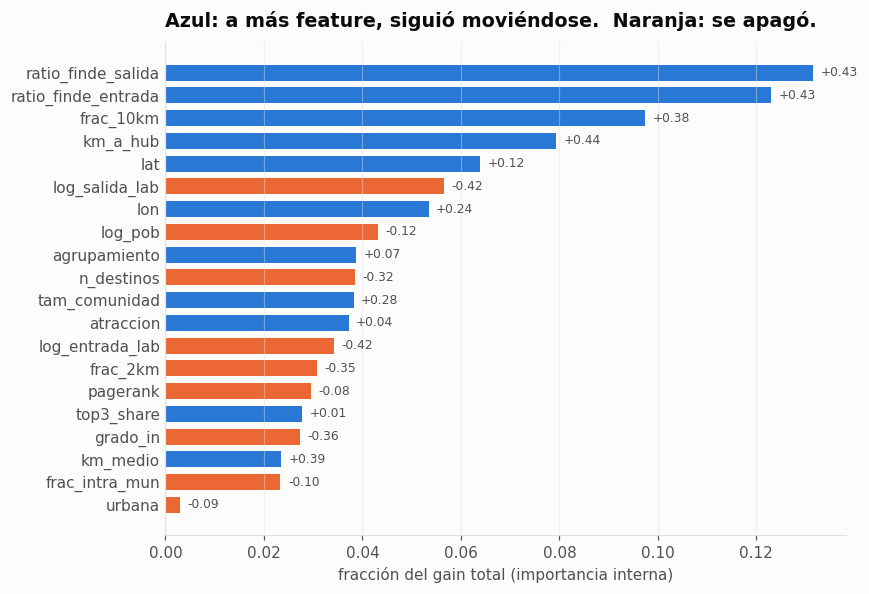

In [33]:
# Barras coloreadas por dirección del efecto
direccion = importancia["dirección (Spearman)"]
orden = imp.sort_values()
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(orden.index, orden.values, color=[AZUL if direccion[c] > 0 else NARANJA for c in orden.index], height=0.7)
for i, c in enumerate(orden.index):
    ax.annotate(f"{direccion[c]:+.2f}", xy=(max(orden[c], 0), i), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=8, color=INK_2)
ax.set(xlabel="fracción del gain total (importancia interna)",
       title="Azul: a más feature, siguió moviéndose.  Naranja: se apagó.")
ax.grid(True, axis="x", alpha=0.4); ax.tick_params(axis="y", length=0)
plt.tight_layout(); plt.show()

Una lectura que conviene hacer con cuidado: `agrupamiento` sale entre las features más
importantes, pero su correlación con el objetivo es casi nula (+0.07). No es una
contradicción: significa que **no actúa sola**. Su efecto depende del valor de otras
features, y un árbol puede aprovechar esa interacción aunque no exista una relación
monótona que una correlación pueda capturar. Las dos columnas de la tabla miden cosas
distintas: la importancia dice cuánto la usa el modelo, la dirección solo describe la
relación lineal de a uno.

## La misma pregunta con SHAP

SHAP resuelve dos cosas que la tabla anterior deja abiertas. La **dirección**: en lugar de
correlacionar cada feature con el objetivo por separado, mira cómo empuja la predicción
*dentro del modelo*, ya descontado el efecto de las demás. Y las **interacciones**: la
gráfica de dependencia de `agrupamiento` muestra con qué otra feature se combina.

Para no romper la honestidad del test espacial, SHAP se calcula **fuera de pliegue**: cada
AGEB se explica con el modelo que se entrenó sin su bloque. El objetivo ya es un logaritmo,
así que los valores SHAP están en las mismas unidades que $y$.

In [34]:
# SHAP fuera de pliegue: cada AGEB se explica con el modelo que no vio su bloque
partes, filas = [], []
for tr, te in cv_espacial.split(X, y_real, bloques):
    m = modelo().fit(X.iloc[tr], y_real.iloc[tr])
    partes.append(shap.TreeExplainer(m)(X.iloc[te])); filas.append(te)
reorden = np.argsort(np.concatenate(filas))
sv_perfil = shap.Explanation(
    values=np.vstack([p.values for p in partes])[reorden],
    base_values=np.concatenate([np.broadcast_to(p.base_values, len(p.values)) for p in partes])[reorden],
    data=X.to_numpy(), feature_names=list(X.columns))

# Importancia media y dirección dentro del modelo, junto a la de Spearman
shap_perfil = pd.DataFrame({
    "|SHAP| medio": np.abs(sv_perfil.values).mean(0),
    "dirección SHAP": [stats.spearmanr(X[c], sv_perfil.values[:, j])[0] for j, c in enumerate(X.columns)],
    "dirección (Spearman)": importancia["dirección (Spearman)"].reindex(X.columns).to_numpy(),
}, index=X.columns).sort_values("|SHAP| medio", ascending=False)
print("Dirección SHAP positiva = a más valor de la feature, el modelo predice que siguió moviéndose.\n")
shap_perfil.round(3).head(10)

Dirección SHAP positiva = a más valor de la feature, el modelo predice que siguió moviéndose.



,|SHAP| medio,dirección SHAP,dirección (Spearman)
ratio_finde_entrada,0.027,0.782,0.427
ratio_finde_salida,0.025,0.643,0.429
km_a_hub,0.021,0.796,0.444
frac_10km,0.020,0.054,0.383
grado_in,0.019,-0.780,-0.364
agrupamiento,0.018,0.933,0.067
lat,0.017,0.247,0.120
log_salida_lab,0.016,-0.711,-0.424
lon,0.014,-0.005,0.236
pagerank,0.013,0.896,-0.080


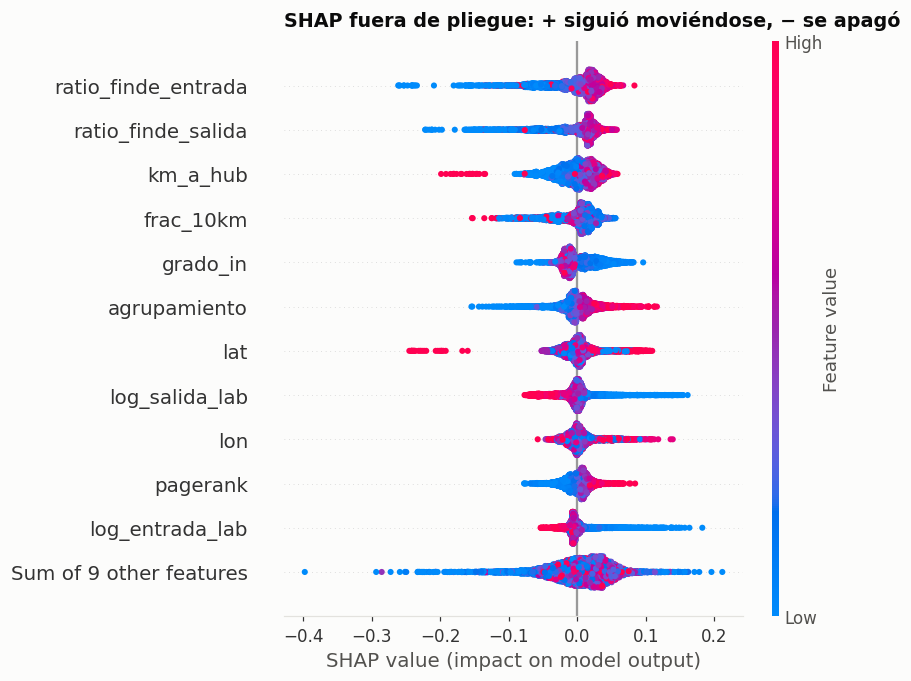

In [35]:
# Beeswarm del perfil: a la derecha siguió moviéndose, a la izquierda se apagó
shap.plots.beeswarm(sv_perfil, max_display=12, show=False)
plt.title("SHAP fuera de pliegue: + siguió moviéndose, − se apagó", loc="left")
plt.tight_layout(); plt.show()

agrupamiento interactúa sobre todo con: log_entrada_lab



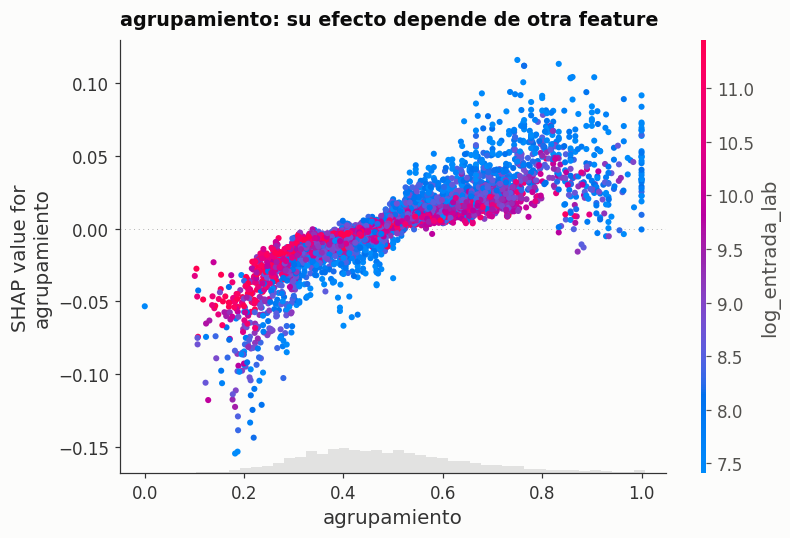

In [36]:
# Dependencia de agrupamiento, coloreada por la feature con la que más interactúa
socia = X.columns[shap.utils.approximate_interactions("agrupamiento", sv_perfil.values, X)[0]]
print(f"agrupamiento interactúa sobre todo con: {socia}\n")
shap.plots.scatter(sv_perfil[:, "agrupamiento"], color=sv_perfil[:, socia], show=False)
plt.title("agrupamiento: su efecto depende de otra feature", loc="left")
plt.tight_layout(); plt.show()

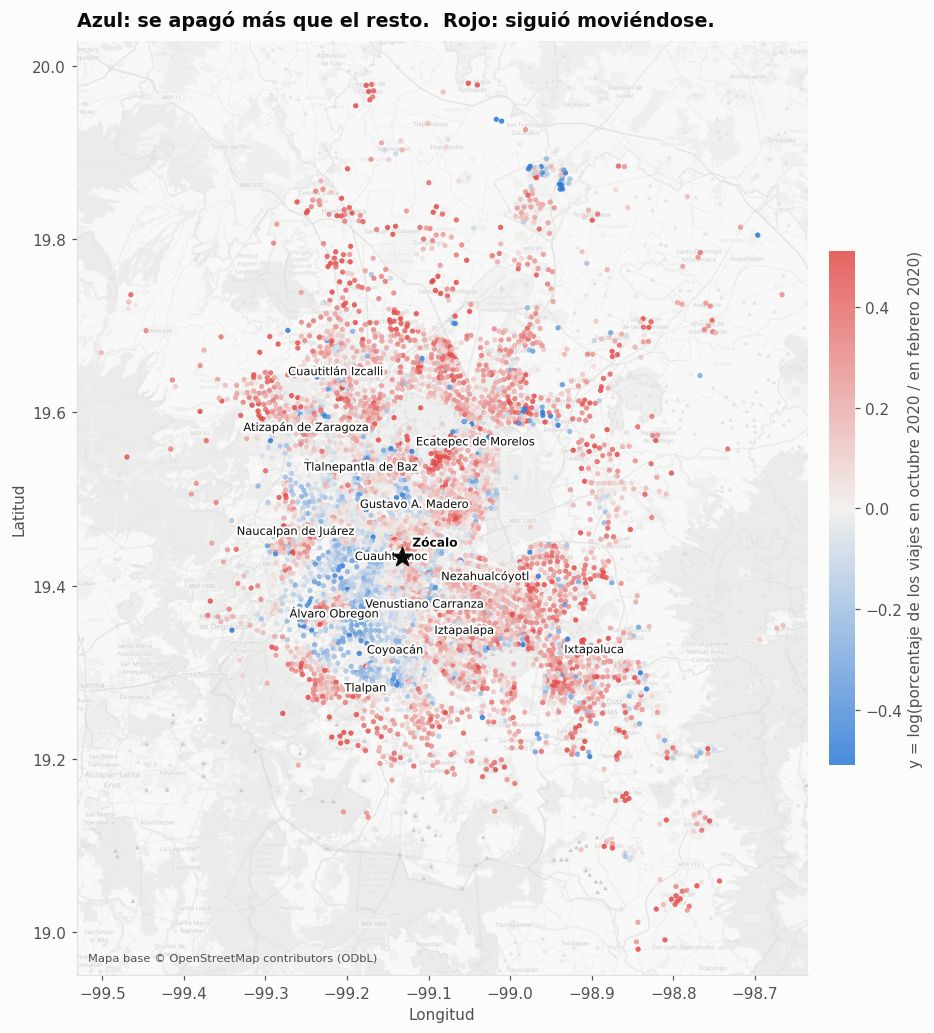

In [37]:
# El mapa, sobre un mapa real muy transparente. El PNG lo deja `descargar_mapa_base.py`
# (tiles de OpenStreetMap ya convertidos a gris claro), así que no necesita red.
# Los tiles son Web Mercator y aquí se dibujan con extensión lon/lat lineal: a esta
# latitud y para este alto, la desviación máxima es de 0.1 km, menos que una AGEB.
lim = np.quantile(np.abs(y_real), 0.95)
fig, ax = plt.subplots(figsize=(10, 9.5))

base_png = Path("mapa_base_zmvm.png")
if base_png.exists():
    ax.imshow(plt.imread(base_png), extent=_json.loads(base_png.with_suffix(".json").read_text())["extent"],
              alpha=0.45, zorder=0, interpolation="bilinear")
    credito = "Mapa base © OpenStreetMap contributors (ODbL)"
else:
    geo_todo = nodos.dropna(subset=["Long", "Lat"])
    ax.scatter(geo_todo.Long, geo_todo.Lat, s=3, c=GRID, linewidths=0, zorder=0)
    credito = "Sin mapa base: corre descargar_mapa_base.py para tenerlo"

# AGEBs coloreados por el objetivo
sc = ax.scatter(X.lon, X.lat, c=y_real, cmap=DIVERGENTE, s=12, linewidths=0, alpha=0.85, zorder=3,
                norm=TwoSlopeNorm(vcenter=0, vmin=-lim, vmax=lim))

# Etiquetas de municipios sin encimarse
geo_todo = nodos.dropna(subset=["Long", "Lat"])
puestas = []
for mun_ in geo_todo.Municipality.value_counts().index[:14]:
    c = geo_todo[geo_todo.Municipality == mun_][["Long", "Lat"]].median()
    px, py_ = c.Long, c.Lat
    while any(abs(px - qx) < 0.085 and abs(py_ - qy) < 0.022 for qx, qy in puestas):
        py_ -= 0.024
    puestas.append((px, py_))
    ax.annotate(mun_, xy=(px, py_), ha="center", va="center", fontsize=7.5, color=INK, zorder=5,
                path_effects=[pe.withStroke(linewidth=3, foreground=SURFACE)])
# Referencia: el Zócalo
ax.scatter([-99.1332], [19.4326], marker="*", s=170, c=INK, zorder=6)
ax.annotate("Zócalo", xy=(-99.1332, 19.4326), xytext=(7, 7), textcoords="offset points", fontsize=8,
            color=INK, fontweight="semibold", zorder=6,
            path_effects=[pe.withStroke(linewidth=3, foreground=SURFACE)])

# Límites, barra de color y títulos
ax.set_xlim(X.lon.min() - 0.03, X.lon.max() + 0.03)
ax.set_ylim(X.lat.min() - 0.03, X.lat.max() + 0.03)
ax.set_aspect(ASPECT)
cb = fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.02); cb.outline.set_visible(False)
cb.set_label("y = log(porcentaje de los viajes en octubre 2020 / en febrero 2020)", color=INK_2)
ax.set(xlabel="Longitud", ylabel="Latitud",
       title="Azul: se apagó más que el resto.  Rojo: siguió moviéndose.")
ax.annotate(credito, xy=(0.015, 0.015), xycoords="axes fraction", fontsize=7.5, color=INK_2)
plt.tight_layout(); plt.show()

In [38]:
# Mediana del objetivo por municipio
por_mun = (pd.DataFrame({"y": y_real, "municipio": nodos.Municipality.reindex(X.index)})
           .groupby("municipio").y.agg(["median", "size"]).query("size >= 20").sort_values("median"))
por_mun["recuperación"] = np.exp(por_mun["median"])
print("Los que más se apagaron:\n")
print(por_mun.head(5).round(3).to_string())
print("\nLos que siguieron moviéndose:\n")
por_mun.tail(5).round(3)

Los que más se apagaron:

                median  size  recuperación
municipio                                 
Miguel Hidalgo  -0.140   130         0.869
Benito Juárez   -0.097   102         0.907
Coyoacán        -0.077   156         0.926
Cuauhtémoc      -0.017   153         0.983
Álvaro Obregón   0.000   197         1.000

Los que siguieron moviéndose:



,median,size,recuperación
municipio,,,
Tultepec,0.306,42,1.358
Zumpango,0.339,33,1.403
Tepotzotlán,0.345,29,1.412
Huehuetoca,0.351,27,1.421
Chicoloapan,0.356,27,1.427


# 6. Resultados ejecutivos

In [41]:
# Tabla resumen con los resultados clave
r2 = lambda o, f, c: R2.loc[(o, f), c]
# R² espacial como media ± desviación estándar de los 5 pliegues
r2e = lambda o, f: f"{r2(o, f, 'R² espacial'):.3f} ± {r2(o, f, 'R² espacial (desv. est.)'):.3f}"
# La lectura del modelo depende de si la diferencia con la media móvil es significativa
lectura_modelo = (f"gana {D_MEDIA7:+.3f} a la media móvil (p = {P_MEDIA7:.1e})" if P_MEDIA7 < 0.05
                  else f"empata con la media móvil: {D_MEDIA7:+.3f}, no significativo (p = {P_MEDIA7:.3f})")
resumen = pd.DataFrame([
    ["Pronóstico", "CPC media móvil 7 días",           f"{CPC_MEDIA7:.3f}",   "resuelto: captura el nivel de cada conexión"],
    ["Pronóstico", "CPC modelo entrenado",             f"{CPC_MODELO:.3f}",   lectura_modelo],
    ["Pandemia",   "Fiabilidad del objetivo",          f"{r_fiab:.3f}",       f"techo aproximado del R²: entre {r_fiab:.2f} y {2*r_fiab/(1+r_fiab):.2f}"],
    ["Pandemia",   "Autocorrelación espacial",         f"{rho_esp:+.3f}",     "los vecinos se parecen: el test debe ser espacial"],
    ["Pandemia",   "R² espacial, features básicas",    r2e('real (oct 2020/feb 2020)', 'básicas'),          "coordenadas, volumen, población"],
    ["Pandemia",   "R² espacial, perfil de movilidad", r2e('real (oct 2020/feb 2020)', 'perfil completo'),  "sin ningún dato externo"],
    ["Pandemia",   "R² aleatorio (inflado)",           f"{r2('real (oct 2020/feb 2020)','perfil completo','R² aleatorio'):.3f}", "proximidad, no aprendizaje; no usar"],
    ["Pandemia",   "R² espacial, control negativo",             r2e('control negativo (feb 2020/ene 2020)', 'perfil completo'), "≈ 0: el método no inventa señal"],
], columns=["Parte", "Medida", "Valor", "Lectura"]).set_index(["Parte", "Medida"])
print("± = desviación estándar entre los 5 pliegues espaciales\n")
# Sin límite de ancho de columna para que no se corte la lectura
from IPython.display import display
with pd.option_context("display.max_colwidth", None):
    display(resumen)

± = desviación estándar entre los 5 pliegues espaciales



Valor  \
Parte      Medida                                             
Pronóstico CPC media móvil 7 días                     0.843   
           CPC modelo entrenado                       0.857   
Pandemia   Fiabilidad del objetivo                    0.768   
           Autocorrelación espacial                  +0.577   
           R² espacial, features básicas      0.075 ± 0.150   
           R² espacial, perfil de movilidad   0.212 ± 0.140   
           R² aleatorio (inflado)                     0.375   
           R² espacial, control negativo     -0.024 ± 0.148   

                                                                                                     Lectura  
Parte      Medida                                                                                             
Pronóstico CPC media móvil 7 días                                resuelto: captura el nivel de cada conexión  
           CPC modelo entrenado              empata con la media móvil: +0.011, no significativo (p = 0.051)  
Pandemia   Fiabilidad del objetivo                                techo aproximado del R²: entre 0.77 y 0.87  
           Autocorrelación espacial                        los vecinos se parecen: el test debe ser espacial  
           R² espacial, features básicas                                     coordenadas, volumen, población  
           R² espacial, perfil de movilidad                                          sin ningún dato externo  
           R² aleatorio (inflado)                                        proximidad, no aprendizaje; no usar  
           R² espacial, control negativo                                     ≈ 0: el método no inventa señal

### Interpretación de los resultados

**Pronóstico: predecir el día siguiente está topado por los datos.**

- La media móvil de 7 días ya coloca el 84 % de los viajes en la conexión correcta.
- El modelo llega al 86 %, pero la diferencia (+0.011) **no es significativa**: en la
  práctica empata con el promedio de la última semana.

**Pandemia: la red sí explica, en parte, quién pudo quedarse en casa.**

- **Fiabilidad (0.77):** el cambio de cada AGEB se repite al medirlo con quincenas
  distintas, así que es un número real y no ruido. El máximo $R^2$ alcanzable está entre
  0.77 y 0.87.
- **Autocorrelación espacial (0.58):** los AGEBs vecinos cambiaron de forma parecida. Por
  eso el modelo se evalúa en zonas que no vio.
- **Features básicas (0.075) contra perfil de movilidad (0.212):** con solo ubicación,
  volumen y población el modelo casi no predice. Al agregar el ratio fin de semana /
  entre semana y la posición en la red, explica cerca de una quinta parte de la
  variación, más o menos una cuarta parte de lo que se puede explicar.
- **$R^2$ aleatorio (0.375):** sale más alto porque el modelo copia a los vecinos. No es
  aprendizaje real y no se usa.
- **Control negativo (−0.024):** entre enero de 2020 y febrero de 2020, sin pandemia, el
  modelo no predice nada. Lo que encuentra en octubre de 2020 es efecto de la pandemia.

**Una precaución.** El ± es grande (alrededor de 0.14): el $R^2$ cambia mucho según la
zona de la ciudad que se deja fuera. Por eso el resultado se lee como **señal clara pero
parcial**, no como un modelo que predice bien.

**En una frase:** solo con datos de la propia red, sin censo ni información externa, se
puede anticipar en parte qué zonas pudieron quedarse en casa durante la pandemia, y en un
periodo sin pandemia el mismo método no encuentra nada.

## Qué decir con esto

1. **El pronóstico de enlaces está topado por el dato.** Una media móvil captura todo lo
   predecible; lo que falta es cuánto se mueve la ciudad cada día (que no se puede
   anticipar) y azar. Ningún modelo lo va a mover con estos archivos.

2. **La respuesta de la ciudad a la pandemia sí se puede explicar desde la propia red.**
   Lo que un AGEB era en febrero de 2020: su ratio fin de semana / entre semana y su posición en el
   grafo: predice si pudo apagarse en octubre de 2020. Pesan sobre todo dos cosas: **de cuántos
   lugares distintos recibe gente** (`grado_in`) y **su ratio fin de semana / entre semana**
   (`ratio_finde_salida`). Las dos describen lo mismo desde ángulos distintos: un centro
   de empleo recibe gente de todas partes y solo tiene actividad de lunes a viernes, y fue el que
   se apagó. Los lugares de vivienda, periféricos y con un ratio cercano a 1, siguieron
   moviéndose. Es inferir uso de suelo desde la red y usarlo para leer la desigualdad de
   la respuesta.

3. **El resultado es honesto:** fiabilidad medida, test espacial estricto, y un control
   negativo que descarta artefactos.

## Qué sigue

- **Datos externos** son la mejora de mayor rendimiento: Censo 2020 por AGEB (internet
  en vivienda, escolaridad, hacinamiento, informalidad) y DENUE (empleo por giro). El
  techo del $R^2$ es del orden de 0.8 y hay mucho margen.
- **Transferencia entre ventanas:** verificar que el modelo entrenado con octubre de 2020
  predice también la recuperación de agosto de 2020 y febrero de 2021.
- **La limitación que hay que declarar:** los porcentajes de los viajes eliminan el encogimiento global
  de la muestra de dispositivos, pero no una posible pérdida *diferencial* de dispositivos por zona. No se
  puede resolver con estos datos; el control negativo y la estabilidad entre ventanas la acotan,
  y una comparación con los índices de movilidad de Google por municipio la cerraría.